Columns assigned: ['ID', 'Current', 'Unit', 'Hours', 'Batch']
First 3 rows:
  ID Current Unit Hours Batch
1  1       0  101     0     1
2  2  0.4741  101   250     1
3  3  0.9255  101   500     1


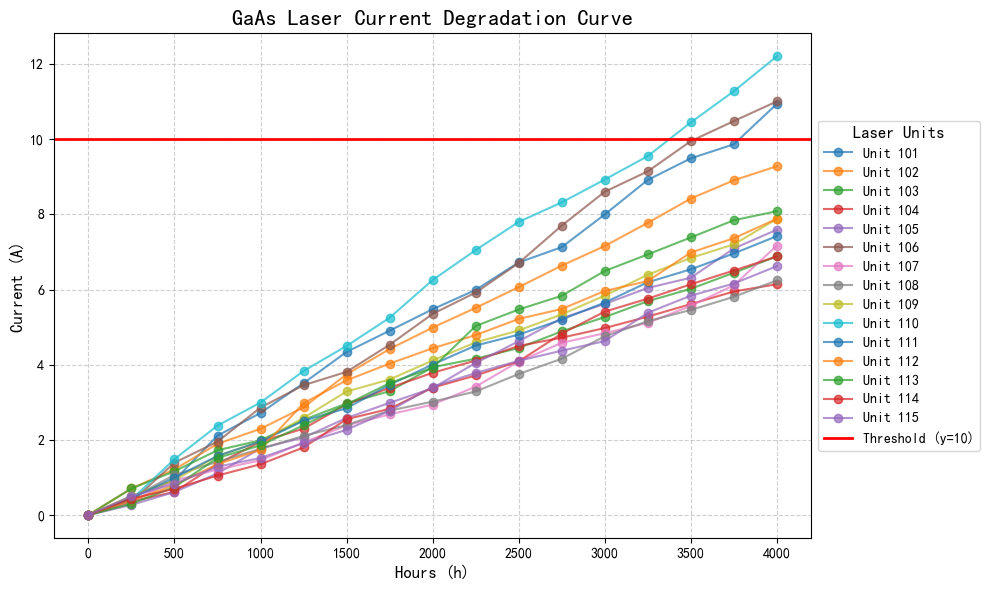

Plotting completed.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r'project1附件-GaAs激光器退化数据.xlsx'

df = pd.read_excel(file_path, skiprows=1, header=None)
    
df.columns = ['ID', 'Current', 'Unit', 'Hours', 'Batch']

df = df[df['Unit'] != '单元']
df = df.dropna(subset=['Hours', 'Current'])

print(f"Columns assigned: {df.columns.tolist()}")
print(f"First 3 rows:\n{df.head(3)}")

df['Hours'] = pd.to_numeric(df['Hours'], errors='coerce')
df['Current'] = pd.to_numeric(df['Current'], errors='coerce')
df['Unit'] = df['Unit'].astype(str) # Treat 'Unit' as a categorical variable

plt.figure(figsize=(10, 6))

grouped = df.groupby('Unit')
    
for name, group in grouped:
    group = group.sort_values('Hours')
    plt.plot(group['Hours'], group['Current'], marker='o', label=f'Unit {name}', alpha=0.7)

plt.axhline(y=10, color='red', linewidth=2, label='Threshold (y=10)')

plt.title('GaAs Laser Current Degradation Curve', fontsize=16)
plt.xlabel('Hours (h)', fontsize=12)
plt.ylabel('Current (A)', fontsize=12)

plt.legend(
    title='Laser Units', 
    bbox_to_anchor=(1.0, 0.5),
    loc='center left',          
    fontsize=10,
    title_fontsize=12
    )    
    
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('Degradation_Curve.svg', bbox_inches='tight')
plt.savefig('Degradation_Curve.pdf', bbox_inches='tight')
plt.show()

print("Plotting completed.")

In [9]:
import numpy as np

unit_list = []
time_list = []
current_list = []

for name, group in grouped:
    group_sorted = group.sort_values('Hours')

    unit_list.append(name)
    time_list.append(group_sorted['Hours'].to_numpy())
    current_list.append(group_sorted['Current'].to_numpy())

units_arr = np.array(unit_list)
time_arr = np.array(time_list) 
current_arr = np.array(current_list)

print(f"Units: {units_arr}")
print(f"Time data shape: {time_arr.shape}(dtype={time_arr.dtype})")
print(f"Current data shape: {current_arr.shape}(dtype={current_arr.dtype})")

print("="*60)
print("Sample time data for each unit:")
for i, unit in enumerate(units_arr):
    print(f"Unit: {unit}")
    print(f"Time data: {time_arr[i]}")
    print(f"Current data: {current_arr[i]}")
    print("-" * 40)

Units: ['101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115']
Time data shape: (15, 17)(dtype=int64)
Current data shape: (15, 17)(dtype=float64)
Sample time data for each unit:
Unit: 101
Time data: [   0  250  500  750 1000 1250 1500 1750 2000 2250 2500 2750 3000 3250
 3500 3750 4000]
Current data: [ 0.      0.4741  0.9255  2.1147  2.7168  3.511   4.3415  4.9076  5.4782
  5.9925  6.7224  7.1303  8.0006  8.9193  9.494   9.8675 10.9446]
----------------------------------------
Unit: 102
Time data: [   0  250  500  750 1000 1250 1500 1750 2000 2250 2500 2750 3000 3250
 3500 3750 4000]
Current data: [0.     0.7078 1.2175 1.8955 2.2954 2.865  3.7454 4.4192 4.9894 5.5148
 6.0668 6.6385 7.1615 7.7778 8.4242 8.9092 9.2834]
----------------------------------------
Unit: 103
Time data: [   0  250  500  750 1000 1250 1500 1750 2000 2250 2500 2750 3000 3250
 3500 3750 4000]
Current data: [0.     0.7074 1.1651 1.7253 1.9888 2.5325 2.9695 3.2977 3.9354 4.1613
 4

In [10]:
from scipy.optimize import curve_fit
import warnings

def exp_model(t, c, d):
    return c * np.exp(d * t.astype(np.float64))

def pow_model(t, c, d):
    return c * np.power(t.astype(np.float64), d)

threshold = 10.0  

results = []

for i, unit in enumerate(units_arr):
    t_data = time_arr[i]
    x_data = current_arr[i]

    valid = ~np.isnan(t_data) & ~np.isnan(x_data)
    t_data = t_data[valid].astype(float)
    x_data = x_data[valid].astype(float)
    
    unit_res = {'Unit': unit}

    try:

        p0_exp = [x_data[0] if len(x_data) > 0 else 1.0, 0.001]
        
        popt_exp, _ = curve_fit(exp_model, t_data, x_data, p0=p0_exp, maxfev=10000)
        c_exp, d_exp = popt_exp
        
        if c_exp > 0 and d_exp != 0:
            ttf_exp = np.log(threshold / c_exp) / d_exp
        else:
            ttf_exp = np.nan
            
        unit_res['Exp_c'] = c_exp
        unit_res['Exp_d'] = d_exp
        unit_res['Exp_TTF (h)'] = ttf_exp
    except Exception as e:
        print(f"单元 {unit} 指数模型拟合失败: {e}")
        unit_res['Exp_c'], unit_res['Exp_d'], unit_res['Exp_TTF (h)'] = np.nan, np.nan, np.nan

    try:

        valid_pow = t_data > 0
        t_data_pow = t_data[valid_pow]
        x_data_pow = x_data[valid_pow]
        
        p0_pow = [x_data_pow[0] if len(x_data_pow) > 0 else 1.0, 0.5]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") 
            popt_pow, _ = curve_fit(pow_model, t_data_pow, x_data_pow, p0=p0_pow, maxfev=10000)
            
        c_pow, d_pow = popt_pow
        
        if c_pow > 0 and d_pow != 0:
            ttf_pow = np.power((threshold / c_pow), 1.0 / d_pow)
        else:
            ttf_pow = np.nan
            
        unit_res['Pow_c'] = c_pow
        unit_res['Pow_d'] = d_pow
        unit_res['Pow_TTF (h)'] = ttf_pow
    except Exception as e:
        print(f"单元 {unit} 幂函数模型拟合失败: {e}")
        unit_res['Pow_c'], unit_res['Pow_d'], unit_res['Pow_TTF (h)'] = np.nan, np.nan, np.nan
        
    results.append(unit_res)

df_results = pd.DataFrame(results)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n" + "="*80)
print("各单元模型拟合参数及预测失效时间 (TTF) 结果汇总:")
print(df_results.round(4)) 

df_results.to_excel('Degradation_Fitting_Results.xlsx', index=False)


各单元模型拟合参数及预测失效时间 (TTF) 结果汇总:
   Unit   Exp_c   Exp_d  Exp_TTF (h)   Pow_c   Pow_d  Pow_TTF (h)
0   101  1.8652  0.0005    3631.5817  0.0028  0.9948    3711.4168
1   102  1.7337  0.0004    3913.5446  0.0033  0.9614    4232.0967
2   103  1.4268  0.0004    4692.3151  0.0059  0.8504    6304.9540
3   104  1.3617  0.0004    4884.3607  0.0059  0.8419    6840.7551
4   105  1.1500  0.0005    4370.8534  0.0008  1.1092    5119.8995
5   106  1.8285  0.0005    3560.4770  0.0018  1.0530    3576.8833
6   107  1.0241  0.0005    4614.2993  0.0008  1.0955    5764.4968
7   108  1.1273  0.0004    4861.5038  0.0023  0.9523    6670.7422
8   109  1.4334  0.0004    4348.4850  0.0030  0.9488    5216.1512
9   110  2.1070  0.0005    3386.6335  0.0033  0.9893    3311.6294
10  111  1.3980  0.0004    4450.9716  0.0031  0.9386    5472.0311
11  112  1.5114  0.0004    4330.0245  0.0039  0.9176    5184.9436
12  113  1.4061  0.0005    4167.1118  0.0015  1.0413    4691.1987
13  114  1.0958  0.0005    4528.0789  0.0008  

✓ Saved: Unit 101 → 101
✓ Saved: Unit 102 → 102
✓ Saved: Unit 103 → 103
✓ Saved: Unit 104 → 104
✓ Saved: Unit 105 → 105
✓ Saved: Unit 106 → 106
✓ Saved: Unit 107 → 107
✓ Saved: Unit 108 → 108
✓ Saved: Unit 109 → 109
✓ Saved: Unit 110 → 110
✓ Saved: Unit 111 → 111
✓ Saved: Unit 112 → 112
✓ Saved: Unit 113 → 113
✓ Saved: Unit 114 → 114
✓ Saved: Unit 115 → 115


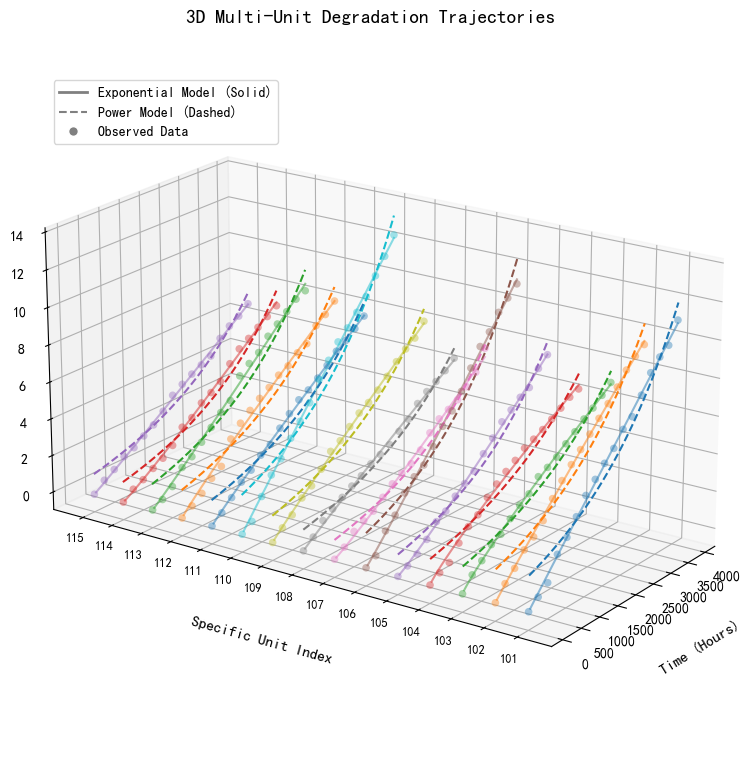

In [11]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import os
import re

# --- 1. 参数与间距设置 ---
spacing_factor = 2.5  
unit_indices = np.arange(len(units_arr)) * spacing_factor

# 稍微增大画布比例，给标签留出空间
fig = plt.figure(figsize=(13, 9)) 
ax = fig.add_subplot(111, projection='3d')
# colors = plt.cm.viridis(np.linspace(0.0, 0.7, len(units_arr)))
colors = plt.cm.tab10(np.arange(len(units_arr))%10)
# colors = plt.cm.Set3(np.linspace(0, 1, len(units_arr)))

# --- 2. 循环绘制数据 ---
for i, unit in enumerate(units_arr):
    t_raw = np.array(time_arr[i], dtype=float)
    c_raw = np.array(current_arr[i], dtype=float)
    y_pos = unit_indices[i]
    
    # 原始观测点
    ax.scatter(t_raw, [y_pos]*len(t_raw), c_raw, color=colors[i], s=30, alpha=0.4, edgecolors='none')

    # 生成拟合曲线 (从0到100)
    t_fit = np.linspace(0, 4000, 100)
    row = df_results[df_results['Unit'] == unit].iloc[0]
    
    # 指数模型 (实线)
    if not np.isnan(row['Exp_c']):
        z_exp = exp_model(t_fit, row['Exp_c'], row['Exp_d'])
        ax.plot(t_fit, [y_pos]*len(t_fit), z_exp, color=colors[i], linestyle='--', linewidth=1.5)

    # 幂函数模型 (虚线)
    if not np.isnan(row['Pow_c']):
        t_fit_pow = t_fit[t_fit > 0]
        z_pow = pow_model(t_fit_pow, row['Pow_c'], row['Pow_d'])
        ax.plot(t_fit_pow, [y_pos]*len(t_fit_pow), z_pow, color=colors[i], linestyle='-', linewidth=1.5, alpha=0.5)

# --- 3. 标签与图例 (优化版) ---

# 坐标轴标签，调大 labelpad 防止重叠
ax.set_xlabel('Time (Hours)', fontsize=11, labelpad=12)
ax.set_ylabel('Specific Unit Index', fontsize=11, labelpad=25) # Unit轴标签往外挪一点
ax.set_zlabel('Current (A)', fontsize=11, labelpad=12)

# Y轴刻度
ax.set_yticks(unit_indices)
ax.set_yticklabels(units_arr, fontsize=9)

# 手动创建自定义图例
legend_elements = [
    Line2D([0], [0], color='gray', lw=2, label='Exponential Model (Solid)'),
    Line2D([0], [0], color='gray', lw=1.5, ls='--', label='Power Model (Dashed)'),
    Line2D([0], [0], marker='o', color='w', label='Observed Data', markerfacecolor='gray', markersize=7)
]
# 调整图例位置，防止遮挡
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.05, 0.95), fontsize=10, frameon=True)

# --- 4. 视角与布局调整 ---
ax.view_init(elev=20, azim=-145) 
ax.set_box_aspect((1, 2.0, 1)) # 视觉拉长 Unit 轴

# 关键：手动控制子图边距，替代 tight_layout()
# 这里的数值(0到1之间)可以根据你的显示屏大小微调
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9)

ax.set_title('3D Multi-Unit Degradation Trajectories', fontsize=14, pad=10)
plt.savefig('Degradation_3D_Vector.svg', bbox_inches='tight')
plt.savefig('Degradation_3D_Vector.pdf', bbox_inches='tight')

# 创建输出目录（自动覆盖特殊字符）
output_dir = "2D_Plots_Unitwise"
os.makedirs(output_dir, exist_ok=True)

# 安全文件名处理函数
def sanitize_filename(name):
    return re.sub(r'[^\w\-_]', '_', str(name).strip())[:50]  # 限制长度防系统错误

# 为每个unit生成独立2D图
for i, unit in enumerate(units_arr):
    try:
        # 创建新画布（避免污染3D图）
        fig2d, ax2d = plt.subplots(figsize=(9, 6), dpi=150)
        
        # --- 绘制数据 ---
        t_raw = np.array(time_arr[i], dtype=float)
        c_raw = np.array(current_arr[i], dtype=float)
        
        # 观测点（提升2D图清晰度）
        ax2d.scatter(t_raw, c_raw, 
                    color=colors[i], s=45, alpha=0.7, 
                    edgecolors='k', linewidth=0.3, 
                    label='Observed Data', zorder=3)
        
        # 获取拟合参数
        row = df_results[df_results['Unit'] == unit].iloc[0]
        
        # 指数模型（虚线）
        if not np.isnan(row['Exp_c']):
            t_fit = np.linspace(0, 4000, 200)  # 增加平滑度
            z_exp = exp_model(t_fit, row['Exp_c'], row['Exp_d'])
            ax2d.plot(t_fit, z_exp, 
                     color=colors[i], linestyle='--', linewidth=2.2,
                     label='Exponential Model (Dashed)', zorder=2)
        
        # 幂函数模型（实线，跳过t=0）
        if not np.isnan(row['Pow_c']):
            t_fit_pow = np.linspace(1, 4000, 200)
            z_pow = pow_model(t_fit_pow, row['Pow_c'], row['Pow_d'])
            ax2d.plot(t_fit_pow, z_pow, 
                     color=colors[i], linestyle='-', linewidth=2.2, alpha=0.85,
                     label='Power Model (Solid)', zorder=1)
        
        # --- 图表美化 ---
        ax2d.set_xlabel('Time (Hours)', fontsize=13, fontweight='bold')
        ax2d.set_ylabel('Current (A)', fontsize=13, fontweight='bold')
        ax2d.set_title(f'Unit {unit} Degradation Curve', fontsize=15, pad=15, fontweight='bold')
        ax2d.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
        ax2d.legend(loc='best', fontsize=11, framealpha=0.95)
        ax2d.tick_params(axis='both', labelsize=11)
        
        # --- 保存文件 ---
        safe_name = sanitize_filename(unit)
        base_path = os.path.join(output_dir, f"Unit_{safe_name}_Degradation")
        fig2d.savefig(f"{base_path}.pdf", bbox_inches='tight')
        fig2d.savefig(f"{base_path}.svg", bbox_inches='tight')
        plt.close(fig2d)  # 释放内存
        
        print(f"✓ Saved: Unit {unit} → {safe_name}")
    
    except Exception as e:
        print(f"✗ Error processing Unit {unit}: {str(e)}")
        plt.close('all')  # 确保异常时释放资源
        continue

plt.show()


In [12]:
from sklearn.metrics import mean_squared_error, r2_score

eval_results = []

for i, unit in enumerate(units_arr):
    t_data = np.array(time_arr[i], dtype=float)
    y_true = np.array(current_arr[i], dtype=float)

    valid = ~np.isnan(t_data) & ~np.isnan(y_true)
    t_data, y_true = t_data[valid], y_true[valid]
    n = len(y_true)
    
    if n == 0: continue

    row = df_results[df_results['Unit'] == unit].iloc[0]
    
    unit_eval = {'Unit': unit}

    if not np.isnan(row['Exp_c']):
        y_pred_exp = exp_model(t_data, row['Exp_c'], row['Exp_d'])
        mse_exp = mean_squared_error(y_true, y_pred_exp)
        r2_exp = r2_score(y_true, y_pred_exp)

        aic_exp = n * np.log(mse_exp) + 2 * 2 
        bic_exp = n * np.log(mse_exp) + 2 * np.log(n)
        
        unit_eval.update({
            'Exp_MSE': mse_exp, 'Exp_R2': r2_exp, 'Exp_AIC': aic_exp
        })
    
    if not np.isnan(row['Pow_c']):
        mask = t_data > 0
        if mask.any():
            y_true_pow = y_true[mask]
            y_pred_pow = pow_model(t_data[mask], row['Pow_c'], row['Pow_d'])
            n_pow = len(y_true_pow)
            
            mse_pow = mean_squared_error(y_true_pow, y_pred_pow)
            r2_pow = r2_score(y_true_pow, y_pred_pow)
            aic_pow = n_pow * np.log(mse_pow) + 2 * 2
            
            unit_eval.update({
                'Pow_MSE': mse_pow, 'Pow_R2': r2_pow, 'Pow_AIC': aic_pow
            })

    if 'Exp_AIC' in unit_eval and 'Pow_AIC' in unit_eval:
        unit_eval['Better_Model'] = 'Exponential' if unit_eval['Exp_AIC'] < unit_eval['Pow_AIC'] else 'Power-Law'
    
    eval_results.append(unit_eval)

df_eval = pd.DataFrame(eval_results)

cols = ['Unit', 'Exp_MSE', 'Pow_MSE', 'Exp_R2', 'Pow_R2', 'Exp_AIC', 'Pow_AIC', 'Better_Model']
df_eval = df_eval[cols]

df_eval.to_excel('Model_Fitting_Evaluation.xlsx', index=False)

print("="*100)
print("模型拟合效果评估表 (AIC 越小代表拟合越优):")
print(df_eval.round(6).to_string(index=False))

winner_counts = df_eval['Better_Model'].value_counts()
print("\n" + "-"*30)
print(f"统计结果：\n{winner_counts}")
print("-"*30)

模型拟合效果评估表 (AIC 越小代表拟合越优):
Unit  Exp_MSE  Pow_MSE   Exp_R2   Pow_R2    Exp_AIC    Pow_AIC Better_Model
 101 0.779867 0.036465 0.929509 0.996290  -0.226734 -48.982235    Power-Law
 102 0.612497 0.011996 0.926890 0.998370  -4.333588 -66.770489    Power-Law
 103 0.303998 0.005162 0.925831 0.998512 -16.242467 -80.263855    Power-Law
 104 0.460219 0.039436 0.879226 0.987960  -9.192912 -47.729315    Power-Law
 105 0.350008 0.012919 0.937929 0.997480 -13.846578 -65.585216    Power-Law
 106 0.756270 0.031885 0.937450 0.997061  -0.749061 -51.130030    Power-Law
 107 0.191285 0.032350 0.954863 0.991515 -24.117813 -50.898100    Power-Law
 108 0.183251 0.017334 0.946512 0.994181 -24.847253 -60.881121    Power-Law
 109 0.406750 0.009837 0.927893 0.998010 -11.292455 -69.946074    Power-Law
 110 0.967948 0.026214 0.929807 0.997856   3.446189 -54.263170    Power-Law
 111 0.390906 0.005761 0.924426 0.998726 -11.967911 -78.506104    Power-Law
 112 0.596969 0.066828 0.899743 0.987210  -4.770141 -39.290239

幂函数拟合得到的各单元 TTF (h):
  Unit  101:  TTF = 3711.42 h
  Unit  102:  TTF = 4232.10 h
  Unit  103:  TTF = 6304.95 h
  Unit  104:  TTF = 6840.76 h
  Unit  105:  TTF = 5119.90 h
  Unit  106:  TTF = 3576.88 h
  Unit  107:  TTF = 5764.50 h
  Unit  108:  TTF = 6670.74 h
  Unit  109:  TTF = 5216.15 h
  Unit  110:  TTF = 3311.63 h
  Unit  111:  TTF = 5472.03 h
  Unit  112:  TTF = 5184.94 h
  Unit  113:  TTF = 4691.20 h
  Unit  114:  TTF = 5475.49 h
  Unit  115:  TTF = 6007.10 h

共 15 个有效 TTF 数据点

两参数 Weibull 分布拟合结果:
  形状参数 β (Shape)  = 5.7487
  尺度参数 η (Scale)  = 5599.21 h
  位置参数 (Location) = 0.0000 (固定为 0)

Weibull 参数已保存至: Weibull_Parameters.xlsx


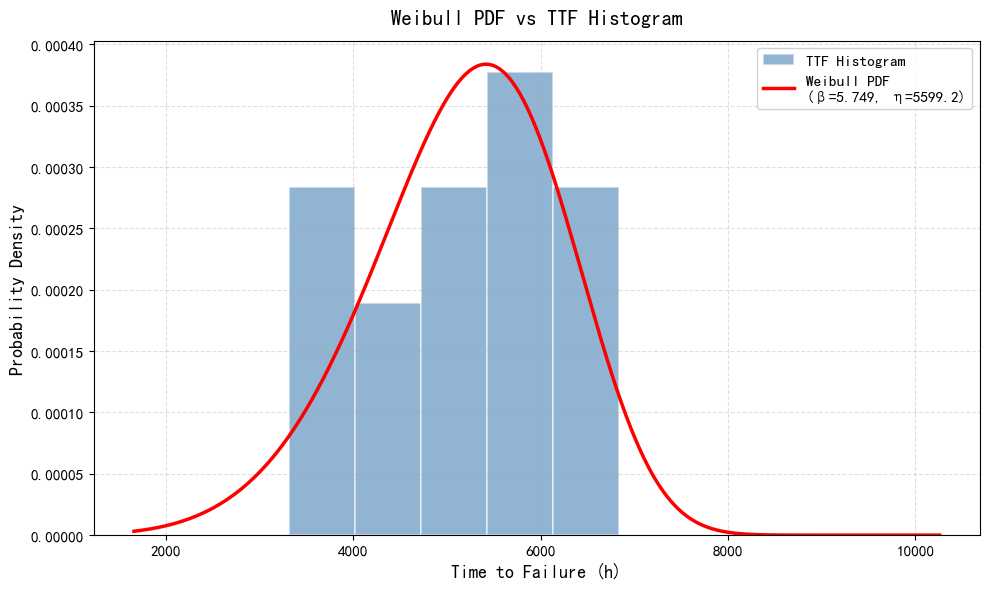

图1已保存: Weibull_PDF_Histogram.pdf / .svg / .png


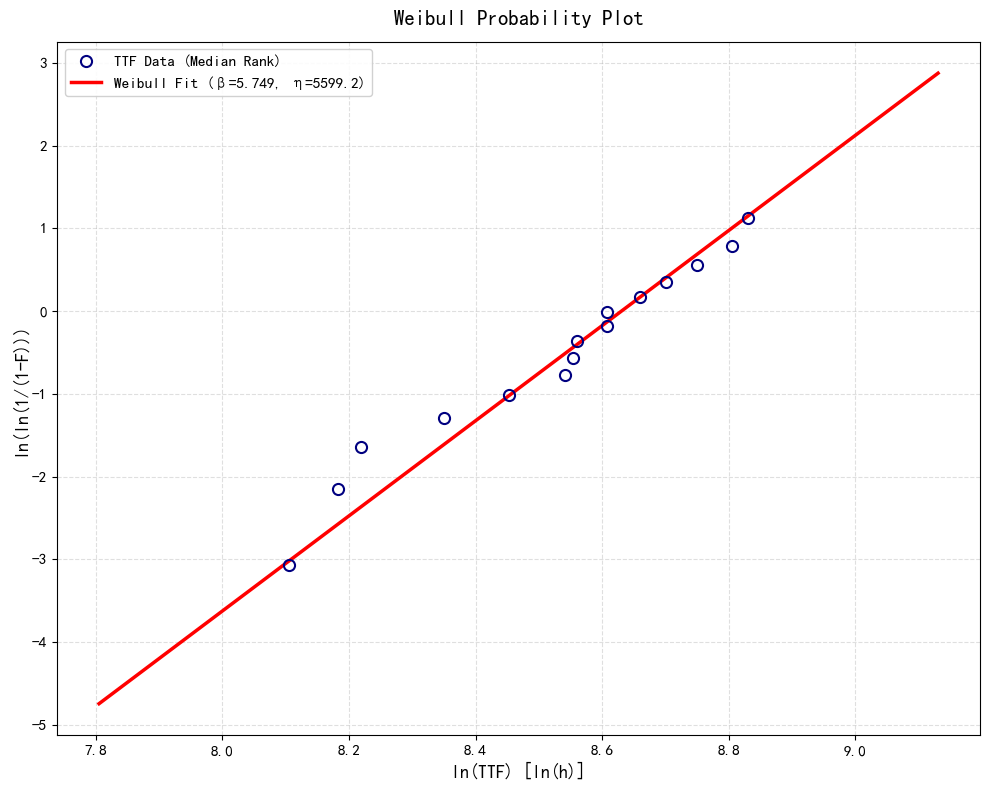

图2已保存: Weibull_Probability_Plot.pdf / .svg / .png

Weibull 分析完毕。


In [31]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ========================================================
# 1. 提取幂函数拟合得到的失效时间 TTF
# ========================================================
ttf_data = df_results['Pow_TTF (h)'].dropna().values
print('=' * 80)
print('幂函数拟合得到的各单元 TTF (h):')
for idx, row in df_results.iterrows():
    if not np.isnan(row['Pow_TTF (h)']):
        print(f"  Unit {int(row['Unit']):>4d}:  TTF = {row['Pow_TTF (h)']:.2f} h")
print(f'\n共 {len(ttf_data)} 个有效 TTF 数据点')

# ========================================================
# 2. 拟合两参数 Weibull 分布 (floc=0 固定位置参数)
#    scipy weibull_min: f(t) = (β/η) * (t/η)^(β-1) * exp(-(t/η)^β)
#    返回: shape=β, loc=0, scale=η
# ========================================================
shape_beta, loc_param, scale_eta = stats.weibull_min.fit(ttf_data, floc=0)

print('\n' + '=' * 80)
print('两参数 Weibull 分布拟合结果:')
print(f'  形状参数 β (Shape)  = {shape_beta:.4f}')
print(f'  尺度参数 η (Scale)  = {scale_eta:.2f} h')
print(f'  位置参数 (Location) = {loc_param:.4f} (固定为 0)')
print('=' * 80)

# ========================================================
# 3. 保存 Weibull 参数到 Excel
# ========================================================
df_weibull_params = pd.DataFrame({
    'Parameter': ['Shape (β)', 'Scale (η)', 'Location'],
    'Value': [shape_beta, scale_eta, loc_param]
})
df_weibull_params.to_excel('Weibull_Parameters.xlsx', index=False)
print('\nWeibull 参数已保存至: Weibull_Parameters.xlsx')

# ========================================================
# 4. 图1: PDF 与 Histogram
# ========================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

# 直方图 (密度归一化)
counts, bins, patches = ax1.hist(
    ttf_data, bins='auto', density=True, alpha=0.6,
    color='steelblue', edgecolor='white', linewidth=1.2,
    label='TTF Histogram'
)
# Weibull PDF 曲线
t_range = np.linspace(max(0, ttf_data.min() * 0.5), ttf_data.max() * 1.5, 500)
pdf_vals = stats.weibull_min.pdf(t_range, shape_beta, loc=0, scale=scale_eta)
ax1.plot(t_range, pdf_vals, 'r-', linewidth=2.5,
         label=f'Weibull PDF\n(β={shape_beta:.3f}, η={scale_eta:.1f})')
ax1.set_xlabel('Time to Failure (h)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax1.set_title('Weibull PDF vs TTF Histogram', fontsize=15, pad=12, fontweight='bold')
ax1.legend(fontsize=11, loc='best', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.tick_params(axis='both', labelsize=11)

fig1.tight_layout()
fig1.savefig('Weibull_PDF_Histogram.pdf', bbox_inches='tight')
fig1.savefig('Weibull_PDF_Histogram.svg', bbox_inches='tight')
plt.show()
print('图1已保存: Weibull_PDF_Histogram.pdf / .svg / .png')

# ========================================================
# 5. 图2: Weibull Probability Plot
# ========================================================
fig2, ax2 = plt.subplots(figsize=(10, 8))

# 排序 TTF 数据并计算经验 CDF (中位秩)
ttf_sorted = np.sort(ttf_data)
n = len(ttf_sorted)
# 中位秩: F_i = (i - 0.3) / (n + 0.4)
median_rank = (np.arange(1, n + 1) - 0.3) / (n + 0.4)

# Weibull 概率坐标变换:
#   x 轴: ln(t)
#   y 轴: ln(ln(1 / (1 - F)))
x_data_plot = np.log(ttf_sorted)
y_data_plot = np.log(np.log(1.0 / (1.0 - median_rank)))

# 绘制数据点
'''
ax2.plot(x_data_plot, y_data_plot, 'bo', markersize=8,
         markeredgecolor='navy', markeredgewidth=1.5,
         label='TTF Data (Median Rank)', zorder=3)
'''

ax2.plot(x_data_plot, y_data_plot, 'bo', markersize=8,
         markerfacecolor='none',  # 关键点：设置内部颜色为无（透明）
         markeredgecolor='navy',  # 圆圈边框颜色
         markeredgewidth=1.5,     # 圆圈边框粗细
         label='TTF Data (Median Rank)', zorder=3)

# 绘制 Weibull 拟合直线
# 理论关系: ln(ln(1/(1-F))) = β * ln(t) - β * ln(η)
x_line = np.linspace(x_data_plot.min() - 0.3, x_data_plot.max() + 0.3, 100)
y_line = shape_beta * x_line - shape_beta * np.log(scale_eta)
ax2.plot(x_line, y_line, 'r-', linewidth=2.5,
         label=f'Weibull Fit (β={shape_beta:.3f}, η={scale_eta:.1f})', zorder=2)

ax2.set_xlabel('ln(TTF) [ln(h)]', fontsize=13, fontweight='bold')
ax2.set_ylabel('ln(ln(1/(1-F)))', fontsize=13, fontweight='bold')
ax2.set_title('Weibull Probability Plot', fontsize=15, pad=12, fontweight='bold')
ax2.legend(fontsize=11, loc='best', framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.tick_params(axis='both', labelsize=11)

fig2.tight_layout()
fig2.savefig('Weibull_Probability_Plot.pdf', bbox_inches='tight')
fig2.savefig('Weibull_Probability_Plot.svg', bbox_inches='tight')
plt.show()
print('图2已保存: Weibull_Probability_Plot.pdf / .svg / .png')

print('\n' + '=' * 80)
print('Weibull 分析完毕。')
print('=' * 80)


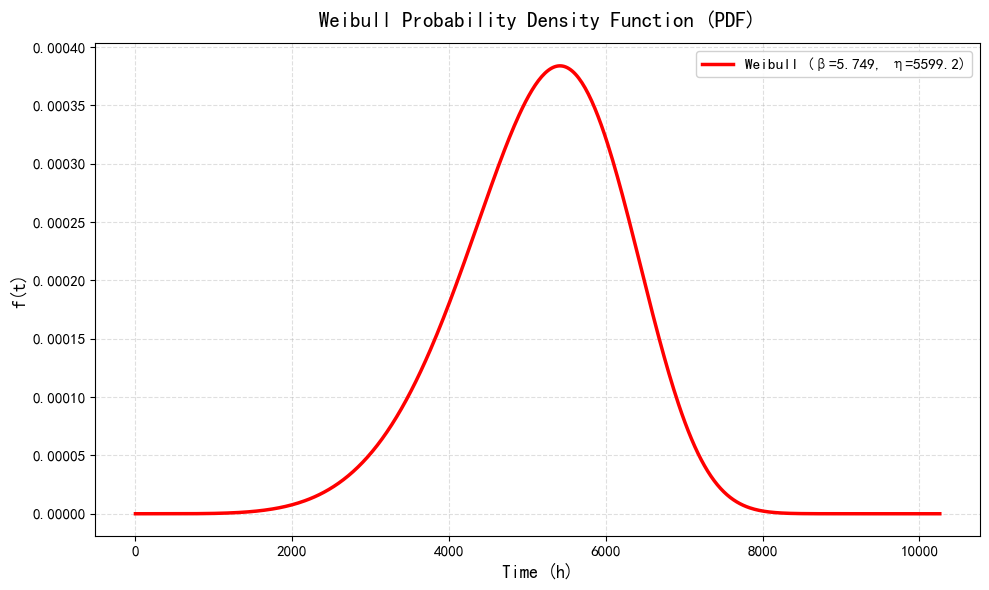

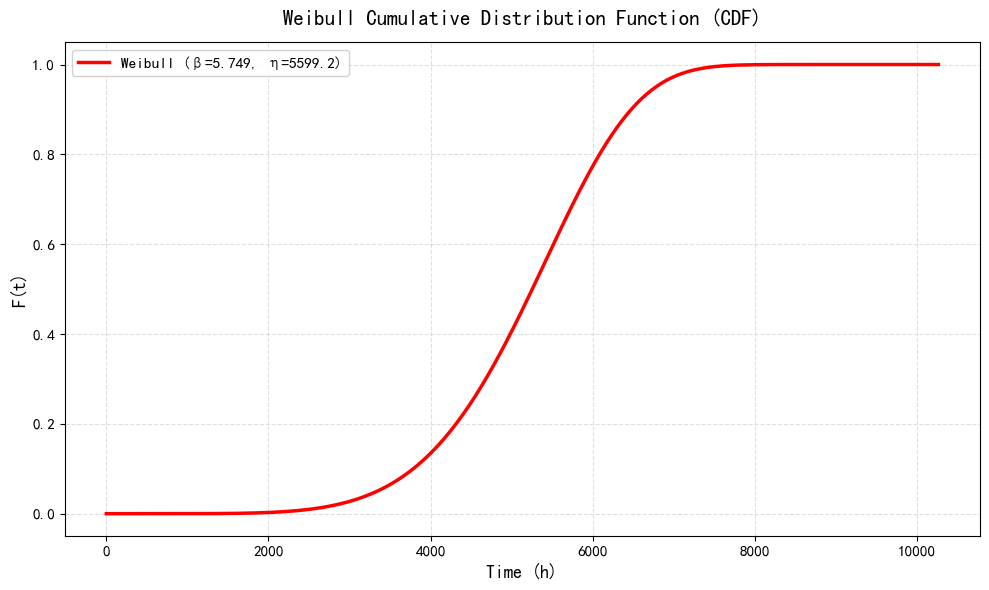

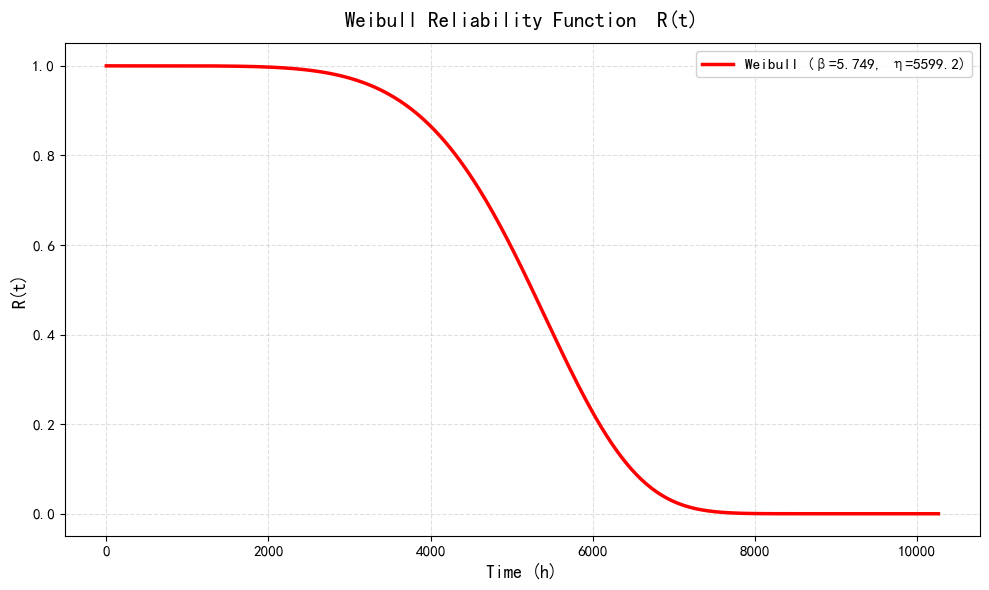

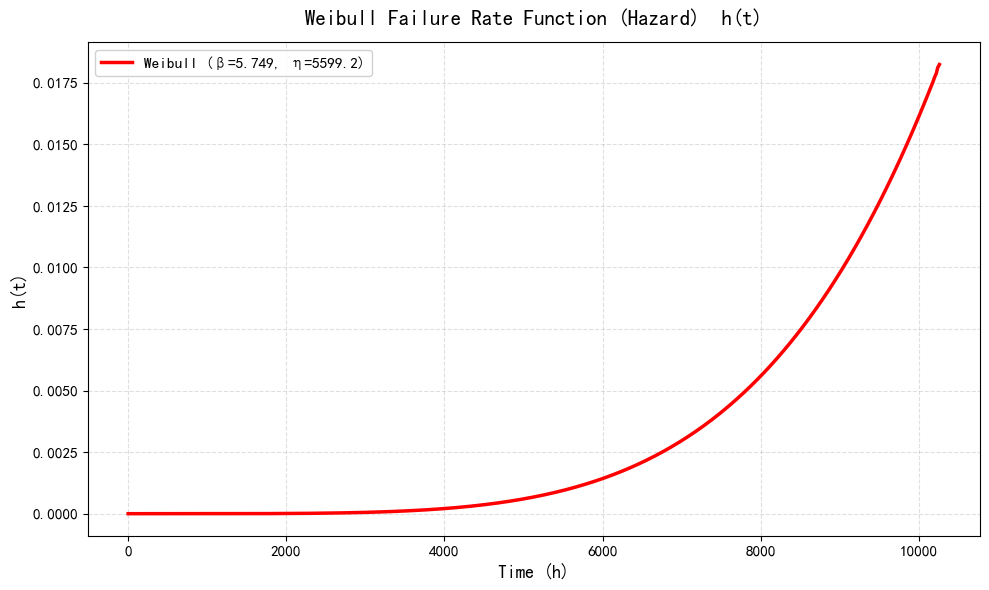

Weibull 四大函数图绘制完毕。


In [32]:
# ================================================================
# Weibull 参数化: PDF / CDF / Reliability / Failure Rate Function
# ================================================================
t_plot = np.linspace(1, ttf_data.max() * 1.5, 500)

wb_pdf  = stats.weibull_min.pdf(t_plot, shape_beta, loc=0, scale=scale_eta)
wb_cdf  = stats.weibull_min.cdf(t_plot, shape_beta, loc=0, scale=scale_eta)
wb_rel  = 1.0 - wb_cdf          # Reliability = 1 - F(t)
wb_haz  = wb_pdf / wb_rel        # Failure Rate h(t) = f(t) / R(t)

titles = ['Probability Density Function (PDF)',
          'Cumulative Distribution Function (CDF)',
          'Reliability Function  R(t)',
          'Failure Rate Function (Hazard)  h(t)']
ylabels = ['f(t)', 'F(t)', 'R(t)', 'h(t)']
data_list = [wb_pdf, wb_cdf, wb_rel, wb_haz]

for title, ylabel, ydata in zip(titles, ylabels, data_list):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(t_plot, ydata, 'r-', linewidth=2.5,
            label=f'Weibull (β={shape_beta:.3f}, η={scale_eta:.1f})')
    ax.set_xlabel('Time (h)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(f'Weibull {title}', fontsize=15, pad=12, fontweight='bold')
    ax.legend(fontsize=11, loc='best', framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='both', labelsize=11)
    fig.tight_layout()
    safe = title.split('(')[0].strip().replace(' ', '_')
    fig.savefig(f'Weibull_{safe}.pdf', bbox_inches='tight')
    fig.savefig(f'Weibull_{safe}.svg', bbox_inches='tight')
    plt.show()

print('Weibull 四大函数图绘制完毕。')


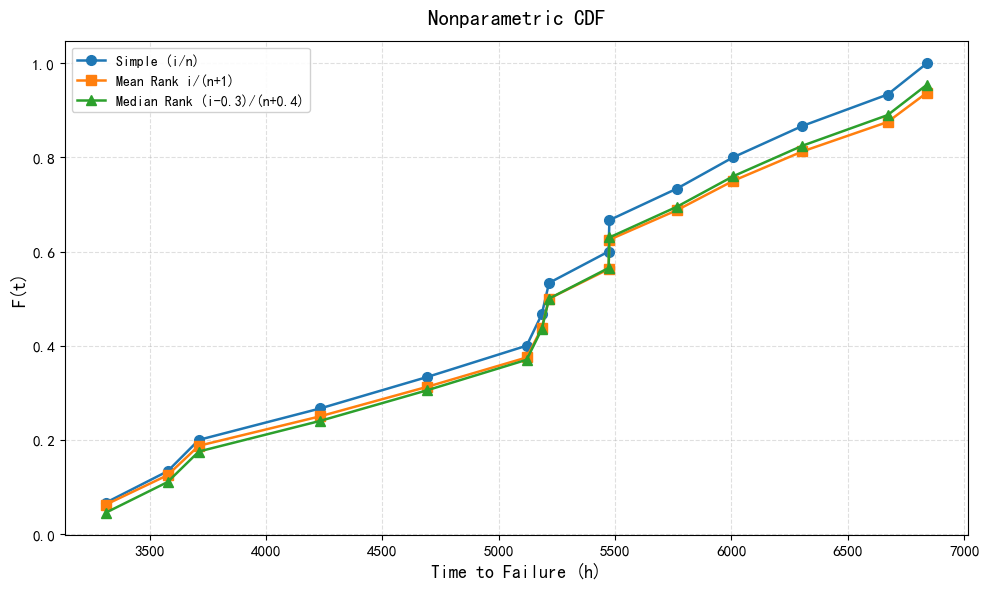

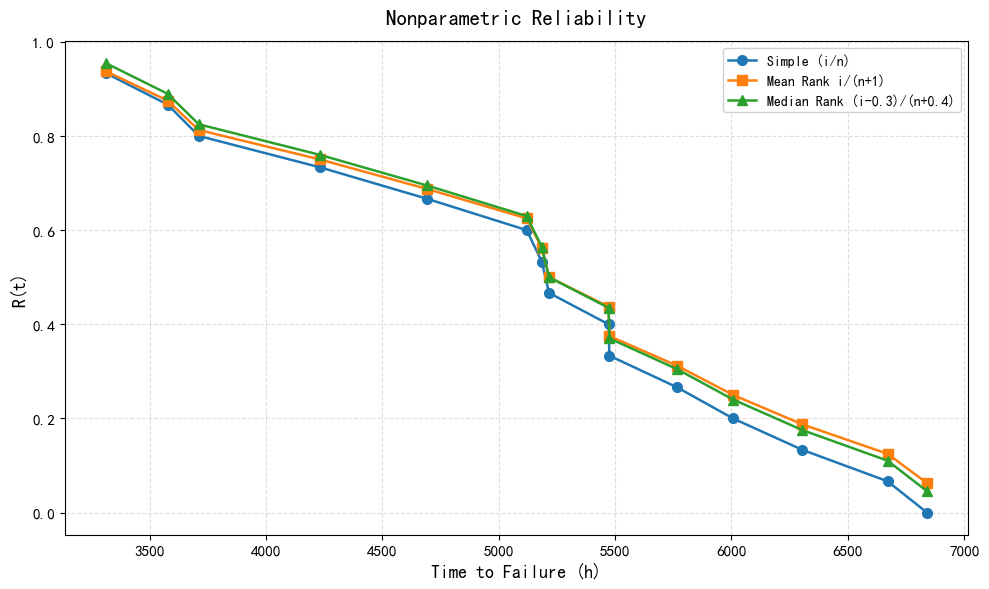

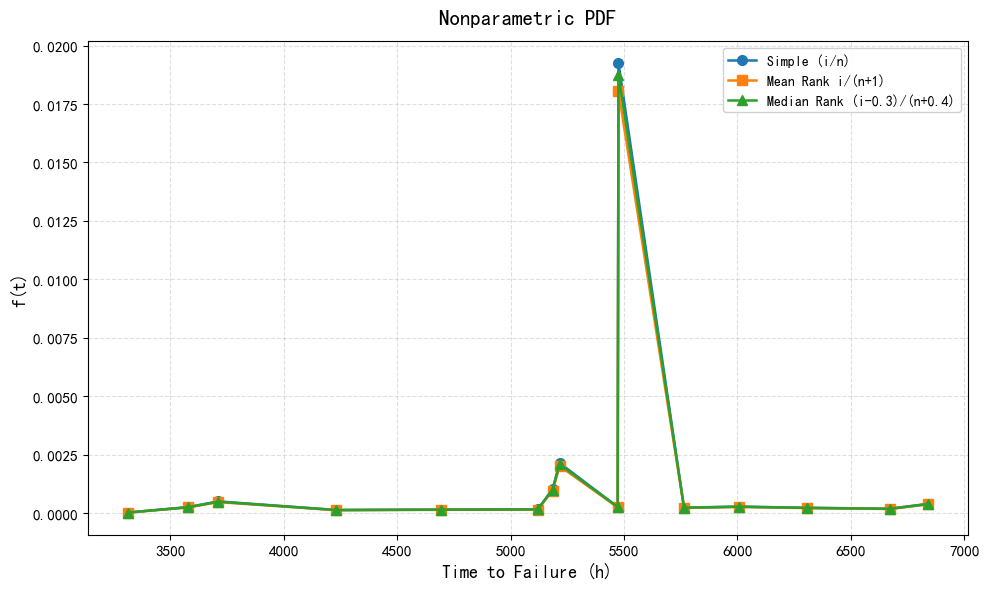

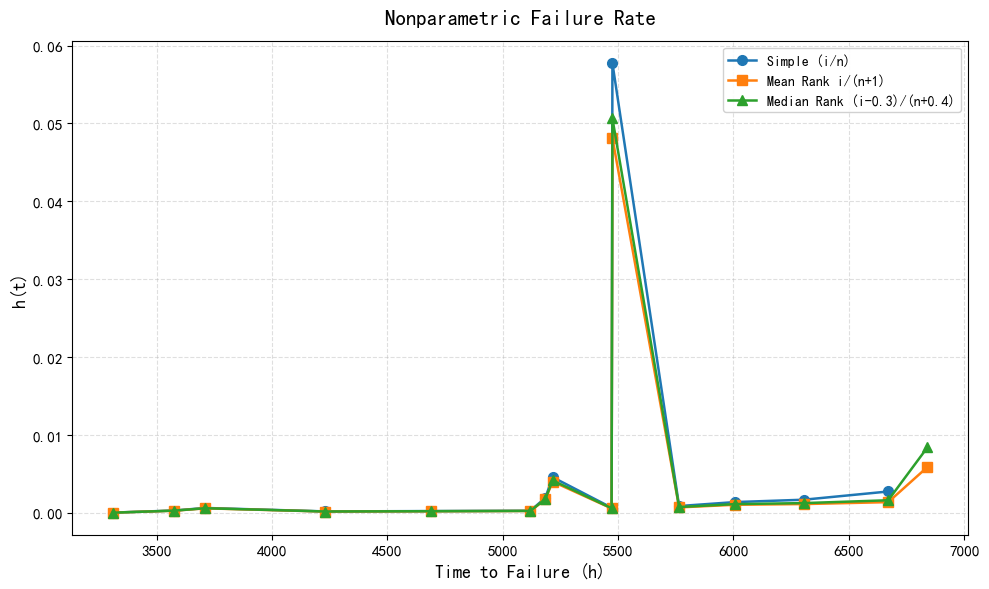

非参数方法四大函数图绘制完毕。


In [15]:
# ================================================================
# 非参数方法: 简单估计 / 平均秩 / 中位秩
# 分别绘制 CDF, Reliability, PDF, Failure Rate（每张图 3 条线）
# ================================================================
ttf_sorted = np.sort(ttf_data)
n = len(ttf_sorted)
ranks = np.arange(1, n + 1)

# 三种经验 CDF 估计
F_simple = ranks / n                               # i/n
F_mean   = ranks / (n + 1)                         # i/(n+1)
F_median = (ranks - 0.3) / (n + 0.4)               # (i-0.3)/(n+0.4)

# Reliability
R_simple = 1.0 - F_simple
R_mean   = 1.0 - F_mean
R_median = 1.0 - F_median

# 经验 PDF（有限差分近似）
def empirical_pdf(t_sorted, F_vals):
    '''中心差分估计 PDF;  边界用前 / 后向差分'''
    f = np.zeros_like(F_vals)
    for i in range(len(F_vals)):
        if i == 0:
            f[i] = F_vals[0] / t_sorted[0]  # 从 0 到第一个点
        else:
            f[i] = (F_vals[i] - F_vals[i-1]) / (t_sorted[i] - t_sorted[i-1])
    return f

f_simple = empirical_pdf(ttf_sorted, F_simple)
f_mean   = empirical_pdf(ttf_sorted, F_mean)
f_median = empirical_pdf(ttf_sorted, F_median)

# Failure Rate h(t) = f(t) / R(t)
h_simple = f_simple / np.where(R_simple > 0, R_simple, np.nan)
h_mean   = f_mean   / np.where(R_mean   > 0, R_mean,   np.nan)
h_median = f_median / np.where(R_median > 0, R_median, np.nan)

# ---- 绘图公共参数 ----
methods  = ['Simple (i/n)', 'Mean Rank i/(n+1)', 'Median Rank (i-0.3)/(n+0.4)']
markers  = ['o', 's', '^']
colors   = ['#1f77b4', '#ff7f0e', '#2ca02c']

plot_cfg = [
    ('CDF',          'F(t)', [F_simple, F_mean, F_median]),
    ('Reliability',  'R(t)', [R_simple, R_mean, R_median]),
    ('PDF',          'f(t)', [f_simple, f_mean, f_median]),
    ('Failure Rate', 'h(t)', [h_simple, h_mean, h_median]),
]

for func_name, ylabel, datasets in plot_cfg:
    fig, ax = plt.subplots(figsize=(10, 6))
    for method, marker, color, ydata in zip(methods, markers, colors, datasets):
        ax.plot(ttf_sorted, ydata, marker=marker, color=color,
                linewidth=1.8, markersize=7, label=method)
    ax.set_xlabel('Time to Failure (h)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(f'Nonparametric {func_name}', fontsize=15, pad=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best', framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='both', labelsize=11)
    fig.tight_layout()
    fig.savefig(f'Nonparametric_{func_name}.pdf', bbox_inches='tight')
    fig.savefig(f'Nonparametric_{func_name}.svg', bbox_inches='tight')
    plt.show()

print('非参数方法四大函数图绘制完毕。')


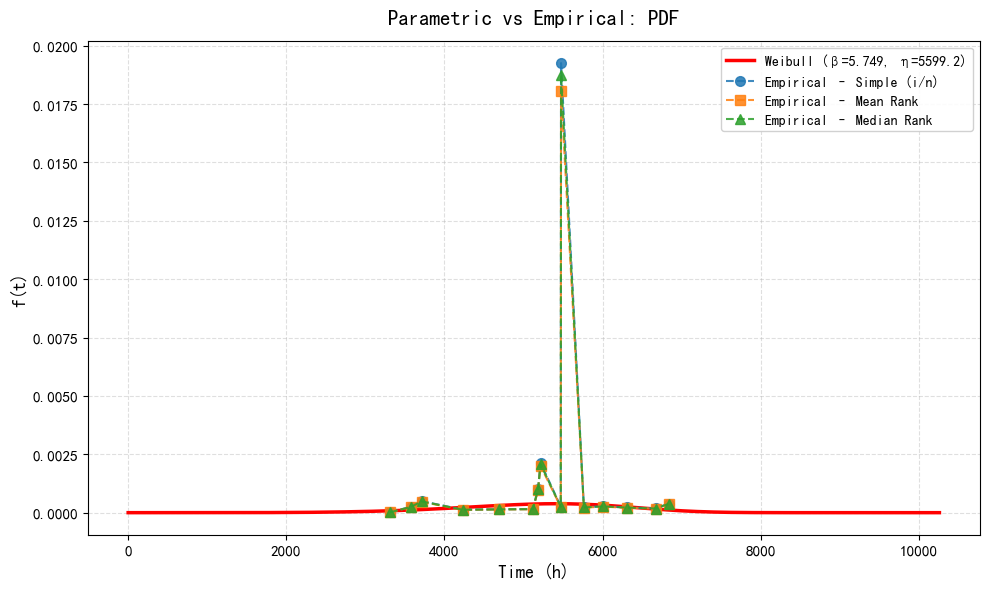

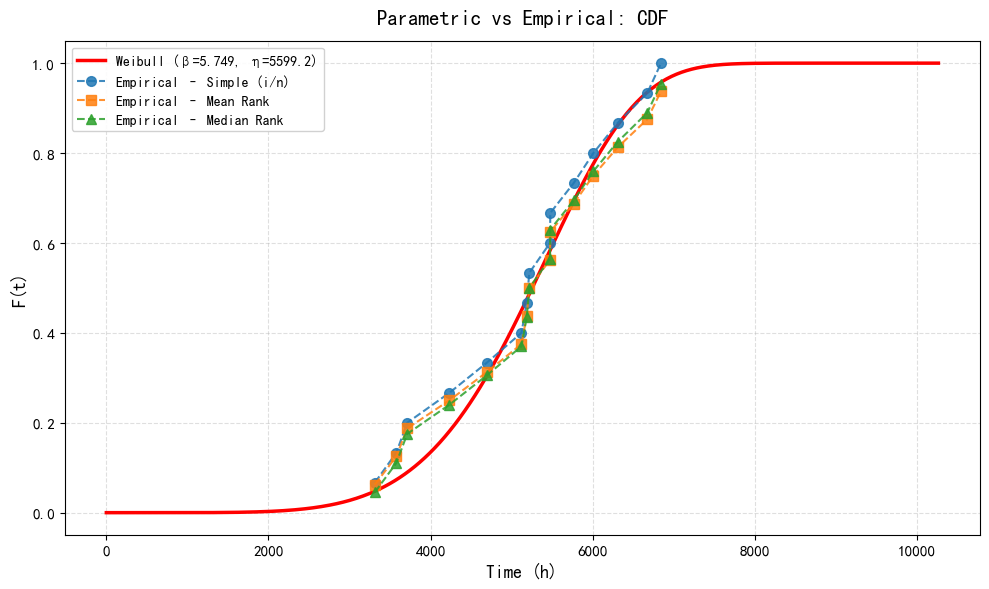

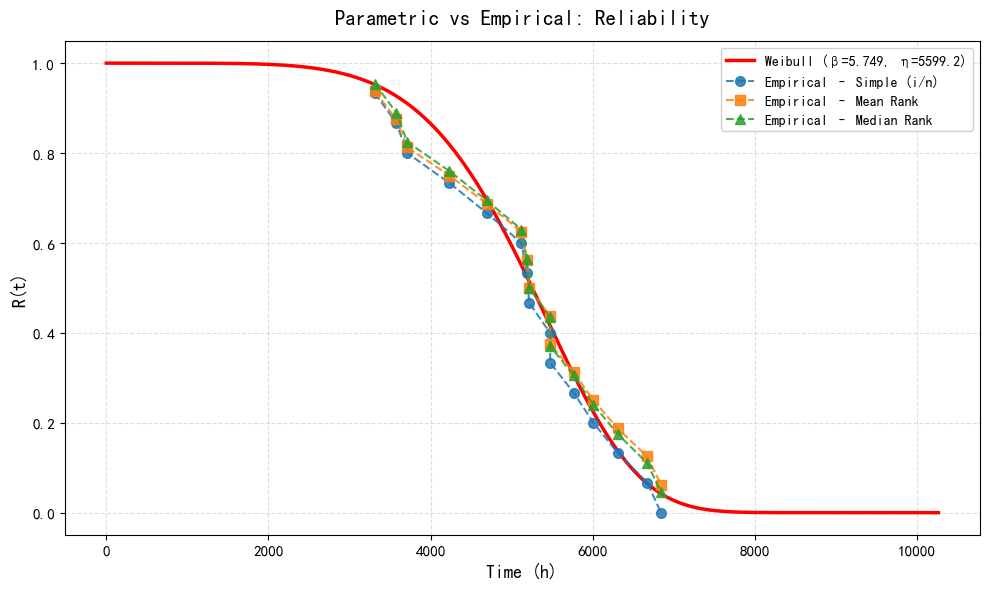

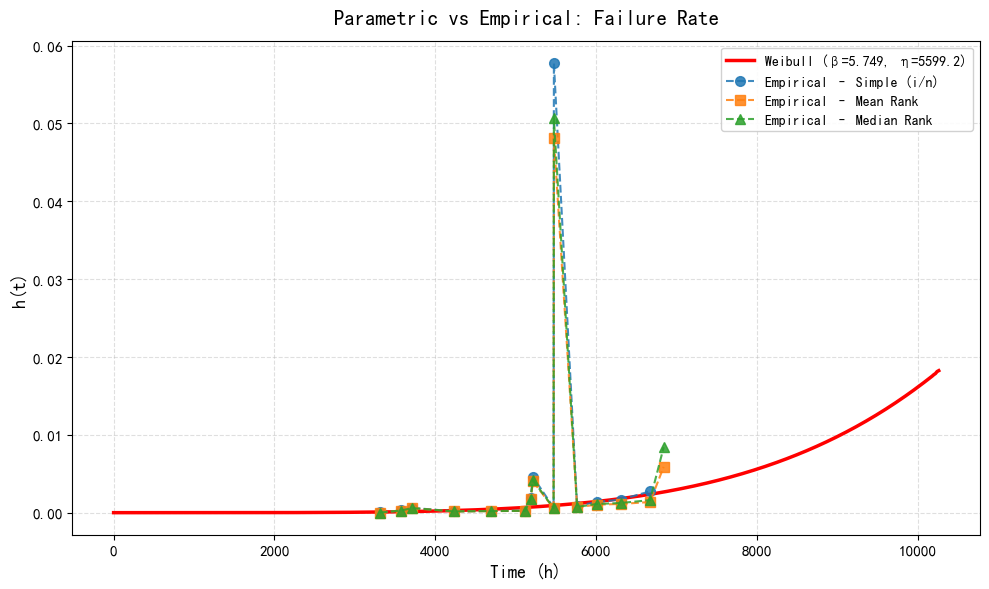

参数法 vs 经验法 对比图绘制完毕。


In [16]:
# ================================================================
# 参数法 (Weibull) vs 经验法 对比
# 四张图: PDF / CDF / Reliability / Failure Rate
# ================================================================
t_wb = np.linspace(1, ttf_data.max() * 1.5, 500)
wb_pdf_c  = stats.weibull_min.pdf(t_wb, shape_beta, loc=0, scale=scale_eta)
wb_cdf_c  = stats.weibull_min.cdf(t_wb, shape_beta, loc=0, scale=scale_eta)
wb_rel_c  = 1.0 - wb_cdf_c
wb_haz_c  = wb_pdf_c / np.where(wb_rel_c > 0, wb_rel_c, np.nan)

compare_cfg = [
    ('PDF',  'f(t)', wb_pdf_c, [f_simple, f_mean, f_median]),
    ('CDF',  'F(t)', wb_cdf_c, [F_simple, F_mean, F_median]),
    ('Reliability', 'R(t)', wb_rel_c, [R_simple, R_mean, R_median]),
    ('Failure Rate','h(t)', wb_haz_c, [h_simple, h_mean, h_median]),
]

emp_labels  = ['Simple (i/n)', 'Mean Rank', 'Median Rank']
emp_markers = ['o', 's', '^']
emp_colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']

for func_name, ylabel, wb_curve, emp_datasets in compare_cfg:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Weibull 参数曲线
    ax.plot(t_wb, wb_curve, 'r-', linewidth=2.5,
            label=f'Weibull (β={shape_beta:.3f}, η={scale_eta:.1f})')

    # 三种经验方法
    for lbl, mkr, clr, ydata in zip(emp_labels, emp_markers, emp_colors, emp_datasets):
        ax.plot(ttf_sorted, ydata, marker=mkr, color=clr,
                linewidth=1.5, markersize=7, linestyle='--', alpha=0.85,
                label=f'Empirical – {lbl}')

    ax.set_xlabel('Time (h)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(f'Parametric vs Empirical: {func_name}',
                 fontsize=15, pad=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best', framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='both', labelsize=11)
    fig.tight_layout()
    fig.savefig(f'Compare_{func_name}.pdf', bbox_inches='tight')
    fig.savefig(f'Compare_{func_name}.svg', bbox_inches='tight')
    plt.show()

print('参数法 vs 经验法 对比图绘制完毕。')


In [17]:
# ================================================================
# Median Life (50% Reliability Time): t at F(t) = 0.5
# ================================================================
from scipy.interpolate import interp1d

# --- Weibull parametric ---
t_median_weibull = stats.weibull_min.ppf(0.5, shape_beta, loc=0, scale=scale_eta)
# 等价公式: η * ln(2)^(1/β)

# --- Empirical (interpolation where F = 0.5) ---
def empirical_median(t_sorted, F_vals, method_name):
    '''线性插值求 F(t)=0.5 对应的 t'''
    if F_vals[-1] < 0.5:
        print(f'  {method_name}: F 最大值 {F_vals[-1]:.4f} < 0.5, 无法插值')
        return np.nan
    if F_vals[0] > 0.5:
        print(f'  {method_name}: F 最小值 {F_vals[0]:.4f} > 0.5, 无法插值')
        return np.nan
    f_interp = interp1d(F_vals, t_sorted, kind='linear')
    return float(f_interp(0.5))

t_median_simple = empirical_median(ttf_sorted, F_simple, 'Simple (i/n)')
t_median_mean   = empirical_median(ttf_sorted, F_mean,   'Mean Rank i/(n+1)')
t_median_median = empirical_median(ttf_sorted, F_median, 'Median Rank')

# --- 汇总结果 ---
print('=' * 70)
print('Median Life  (50%% Reliability Time,  F(t) = 0.5)')
print('=' * 70)
print(f'  Weibull  (beta={shape_beta:.4f}, eta={scale_eta:.2f}):  {t_median_weibull:.2f} h')
print(f'  Empirical - Simple   (i/n)          :  {t_median_simple:.2f} h')
print(f'  Empirical - Mean Rank i/(n+1)       :  {t_median_mean:.2f} h')
print(f'  Empirical - Median Rank (i-0.3)/(n+0.4): {t_median_median:.2f} h')
print('=' * 70)

# 保存到 Excel
df_median = pd.DataFrame({
    'Method': ['Weibull Parametric',
               'Empirical - Simple (i/n)',
               'Empirical - Mean Rank i/(n+1)',
               'Empirical - Median Rank (i-0.3)/(n+0.4)'],
    'Median Life (h)': [t_median_weibull,
                        t_median_simple,
                        t_median_mean,
                        t_median_median]
})
df_median.to_excel('Median_Life_Comparison.xlsx', index=False)
print('\nMedian Life 对比已保存至: Median_Life_Comparison.xlsx')


Median Life  (50%% Reliability Time,  F(t) = 0.5)
  Weibull  (beta=5.7487, eta=5599.21):  5253.36 h
  Empirical - Simple   (i/n)          :  5200.55 h
  Empirical - Mean Rank i/(n+1)       :  5216.15 h
  Empirical - Median Rank (i-0.3)/(n+0.4): 5216.15 h

Median Life 对比已保存至: Median_Life_Comparison.xlsx


In [18]:
# ================================================================
# Wiener Process Parameters Estimation (MLE) using Degradation Data
# Model: y(t) - y(t-1) ~ N(mu * dt, sigma^2 * dt)
# ================================================================
import numpy as np
import pandas as pd

wiener_results = []

# 用于全局 MLE 的累积数据
all_dy = []
all_dt = []

for i, unit in enumerate(units_arr):
    t_data = time_arr[i]
    y_data = current_arr[i]  # degradation data is current_arr

    valid = ~np.isnan(t_data) & ~np.isnan(y_data)
    t_data = t_data[valid].astype(float)
    y_data = y_data[valid].astype(float)
    
    # 确保时间按升序排列从而正确计算增量
    sort_idx = np.argsort(t_data)
    t_data = t_data[sort_idx]
    y_data = y_data[sort_idx]
    
    # 计算增量
    dt = np.diff(t_data)
    dy = np.diff(y_data)
    
    # 避免 dt <= 0 导致的除 0 错误
    valid_diff = dt > 0
    dt = dt[valid_diff]
    dy = dy[valid_diff]
    
    N = len(dt)
    if N == 0:
        continue
        
    # 单个 Unit 的 MLE 估计
    # mu_hat = sum(dy) / sum(dt)
    # sigma^2_hat = sum((dy - mu_hat * dt)^2 / dt) / N
    mu_hat = np.sum(dy) / np.sum(dt)
    sigma2_hat = np.sum(((dy - mu_hat * dt) ** 2) / dt) / N
    
    wiener_results.append({
        'Unit': unit,
        'mu': mu_hat,
        'sigma2': sigma2_hat
    })
    
    all_dy.extend(dy)
    all_dt.extend(dt)

df_wiener = pd.DataFrame(wiener_results)

# 全局 (Pooled) MLE 估计
all_dy = np.array(all_dy)
all_dt = np.array(all_dt)
mu_global = np.sum(all_dy) / np.sum(all_dt)
sigma2_global = np.sum(((all_dy - mu_global * all_dt) ** 2) / all_dt) / len(all_dt)

# 打印结果
print('=' * 80)
print('Wiener Process MLE Parameters (Unit-Specific)')
print('=' * 80)
for idx, row in df_wiener.iterrows():
    print(f"  Unit {int(row['Unit']):>4d} | Drift (mu) = {row['mu']:.6e} | Diffusion squared (sigma^2) = {row['sigma2']:.6e}")

print('\n' + '=' * 80)
print('Wiener Process MLE Parameters (Global / Pooled)')
print('=' * 80)
print(f"  Global Drift (mu)               = {mu_global:.6e}")
print(f"  Global Diffusion squared(sigma^2) = {sigma2_global:.6e}")
print('=' * 80)

# 保存至 Excel
df_wiener.to_excel('Wiener_Process_MLE.xlsx', index=False)


Wiener Process MLE Parameters (Unit-Specific)
  Unit  101 | Drift (mu) = 2.736150e-03 | Diffusion squared (sigma^2) = 2.200685e-04
  Unit  102 | Drift (mu) = 2.320850e-03 | Diffusion squared (sigma^2) = 5.668634e-05
  Unit  103 | Drift (mu) = 1.721225e-03 | Diffusion squared (sigma^2) = 6.608489e-05
  Unit  104 | Drift (mu) = 1.535950e-03 | Diffusion squared (sigma^2) = 8.978076e-05
  Unit  105 | Drift (mu) = 1.898525e-03 | Diffusion squared (sigma^2) = 8.921499e-05
  Unit  106 | Drift (mu) = 2.752400e-03 | Diffusion squared (sigma^2) = 1.698174e-04
  Unit  107 | Drift (mu) = 1.793075e-03 | Diffusion squared (sigma^2) = 1.614617e-04
  Unit  108 | Drift (mu) = 1.561250e-03 | Diffusion squared (sigma^2) = 4.179947e-05
  Unit  109 | Drift (mu) = 1.971200e-03 | Diffusion squared (sigma^2) = 5.655205e-05
  Unit  110 | Drift (mu) = 3.052500e-03 | Diffusion squared (sigma^2) = 1.216240e-04
  Unit  111 | Drift (mu) = 1.855950e-03 | Diffusion squared (sigma^2) = 3.521647e-05
  Unit  112 | Drift

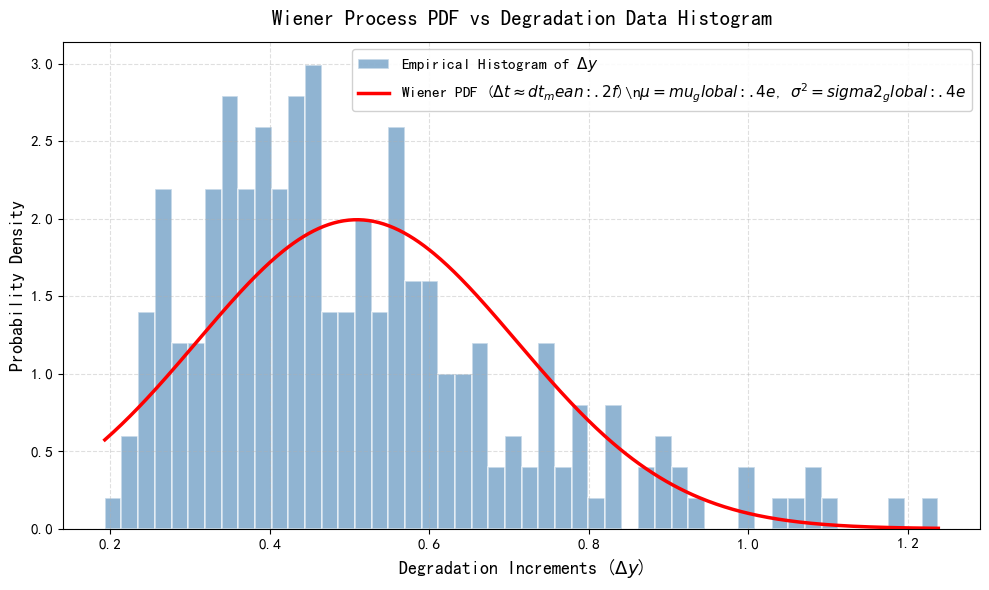

In [19]:
# ================================================================
# Plot the PDF of the Wiener process model alongside
# the histogram of the actual degradation data increments.
# ================================================================
import scipy.stats as stats
import matplotlib.pyplot as plt

# 使用平均增量时间 dt 来计算理论的 PDF，若测试采样时间固定则等价于恒定 dt
dt_mean = np.mean(all_dt)

fig, ax = plt.subplots(figsize=(10, 6))

# 实际退化增量数据的直方图
counts, bins, patches = ax.hist(
    all_dy, bins=50, density=True, alpha=0.6,
    color='steelblue', edgecolor='white', linewidth=1.2,
    label=r'Empirical Histogram of $\Delta y$'
)

# 理论 Wiener 过程的 PDF: N(mu * dt, sigma^2 * dt)
y_range = np.linspace(all_dy.min(), all_dy.max(), 500)
theory_mean = mu_global * dt_mean
theory_std  = np.sqrt(sigma2_global * dt_mean)
pdf_vals = stats.norm.pdf(y_range, loc=theory_mean, scale=theory_std)

ax.plot(y_range, pdf_vals, 'r-', linewidth=2.5,
         label=r'Wiener PDF ($\Delta t \approx {dt_mean:.2f}$)\n$\mu={mu_global:.4e}$, $\sigma^2={sigma2_global:.4e}$')

ax.set_xlabel(r'Degradation Increments ($\Delta y$)', fontsize=13, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax.set_title('Wiener Process PDF vs Degradation Data Histogram', fontsize=15, pad=12, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='both', labelsize=11)
fig.tight_layout()

fig.savefig('Wiener_PDF_vs_Histogram.svg', bbox_inches='tight')
fig.savefig('Wiener_PDF_vs_Histogram.pdf', bbox_inches='tight')
plt.show()


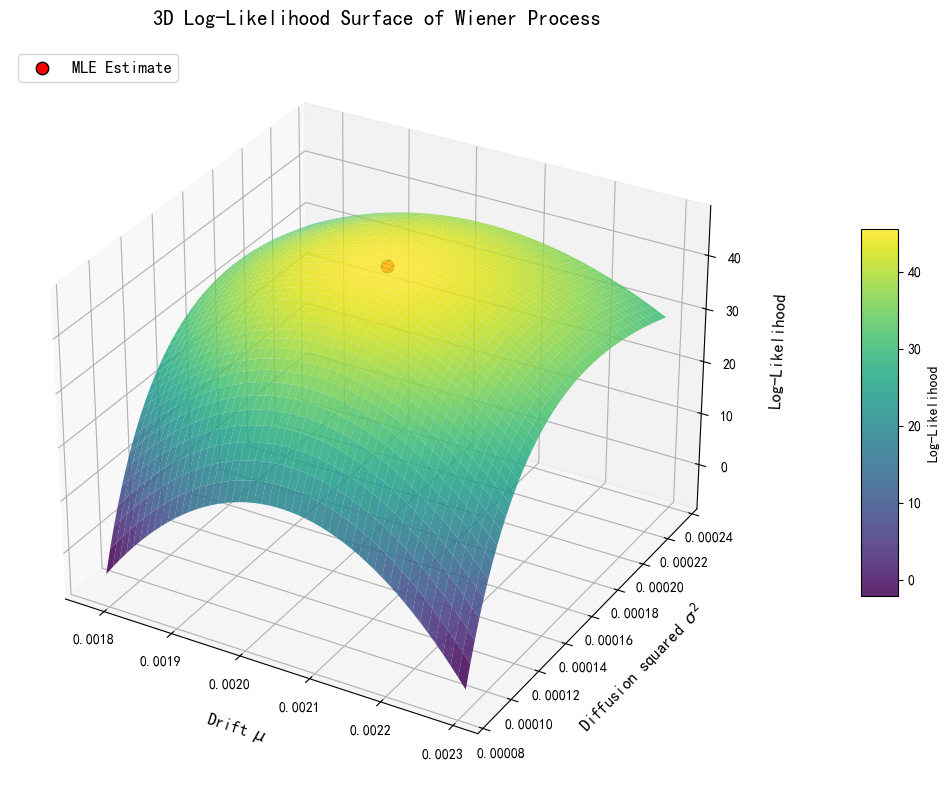

3D 对数似然图绘制完毕，可以明显看到 MLE 位于函数曲面峰值处。


In [20]:
# ================================================================
# 3D Visualization of the Log-Likelihood Function
# Varying mu and squared sigma to verify the effectivity of MLE.
# ================================================================
from mpl_toolkits.mplot3d import Axes3D

def log_likelihood(mu, sigma2, dy_arr, dt_arr):
    '''计算 Wiener 过程增量的对数似然值'''
    N = len(dy_arr)
    # 为了避免不可见或极小的似然值，加上了所有的常数项进行精确计算
    ll = - (N / 2) * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(np.log(dt_arr)) \
         - np.sum(((dy_arr - mu * dt_arr) ** 2) / dt_arr) / (2 * sigma2)
    return ll

# 基于统计学的标准误差(Standard Error)设置计算网格的范围，
# 这样可以确保极值点(MLE)正好处于网格中间，并且图形高度平滑。
se_mu = np.sqrt(sigma2_global / np.sum(all_dt))
se_sigma2 = np.sqrt(2 * sigma2_global**2 / len(all_dt))

# 取 MLE 估计值上下 +/- 5 倍标准误的区间
mu_vals = np.linspace(mu_global - 5 * se_mu, mu_global + 5 * se_mu, 50)
sigma2_vals = np.linspace(max(1e-12, sigma2_global - 5 * se_sigma2), sigma2_global + 5 * se_sigma2, 50)

MU, SIGMA2 = np.meshgrid(mu_vals, sigma2_vals)
LL = np.zeros_like(MU)

# 计算每个网格点上的 Log-Likelihood
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        LL[i, j] = log_likelihood(MU[i, j], SIGMA2[i, j], all_dy, all_dt)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制对数似然曲面
surf = ax.plot_surface(MU, SIGMA2, LL, cmap='viridis', edgecolor='none', alpha=0.85)

# 用红点标记我们在上一部分计算出的全局 MLE 参数点
max_ll = log_likelihood(mu_global, sigma2_global, all_dy, all_dt)
ax.scatter([mu_global], [sigma2_global], [max_ll], color='red', s=80, marker='o',
           edgecolor='black', label='MLE Estimate', zorder=5)

ax.set_xlabel(r'Drift $\mu$', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel(r'Diffusion squared $\sigma^2$', fontsize=12, fontweight='bold', labelpad=12)
ax.set_zlabel('Log-Likelihood', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('3D Log-Likelihood Surface of Wiener Process', fontsize=15, pad=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')

# 添加色带颜色条
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Log-Likelihood')

plt.tight_layout()
fig.savefig('Wiener_3D_Likelihood_Surface.svg', bbox_inches='tight')
fig.savefig('Wiener_3D_Likelihood_Surface.pdf', bbox_inches='tight')
plt.show()

print('=' * 80)
print('3D 对数似然图绘制完毕，可以明显看到 MLE 位于函数曲面峰值处。')
print('=' * 80)


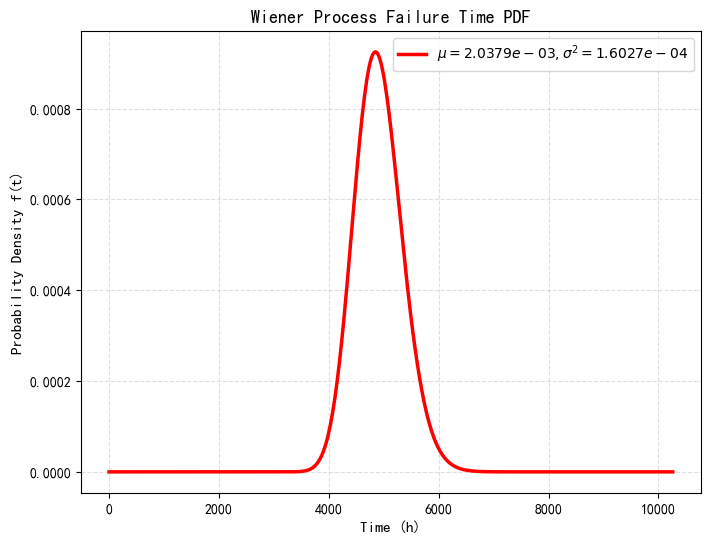

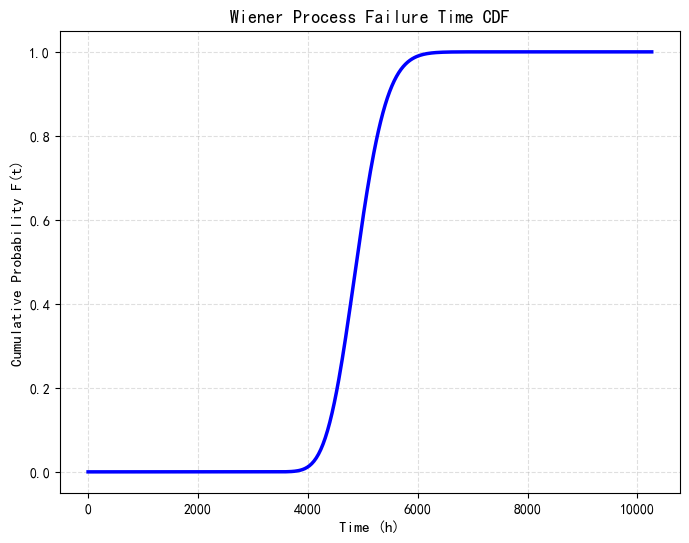

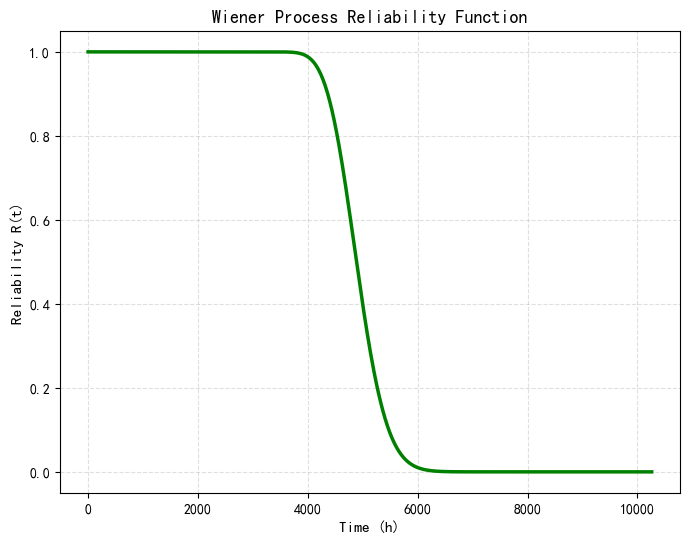

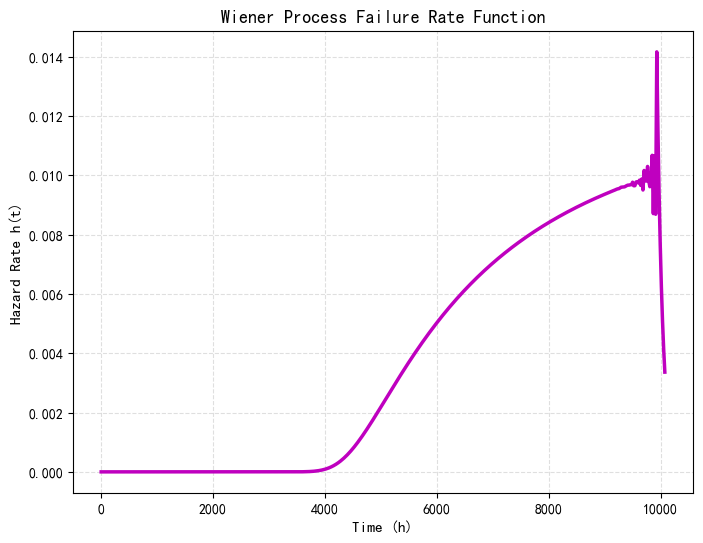

WP Failure Time Functions plotted as separate figures and saved.

********************************************************************************
  Median Life (50% Reliability Time) derived from Wiener Process Degradation Model:
          >>>>>  4887.79 h  <<<<<
********************************************************************************



In [34]:
# ================================================================
# First Hitting Time (Failure Time) Distribution based on Wiener Process
# CDF, PDF, Reliability, and Failure Rate (Hazard) Functions
# Calculation of Median Life (50% Reliability Time)
# ================================================================
from scipy.stats import norm
from scipy.optimize import root_scalar

def wp_pdf(t, mu, sigma2, L):
    '''失效时间的概率密度函数 (Inverse Gaussian distribution PDF)'''
    return (L / np.sqrt(2 * np.pi * sigma2 * t**3)) * np.exp(- ((L - mu * t)**2) / (2 * sigma2 * t))

def wp_cdf(t, mu, sigma2, L):
    '''失效时间的累积分布函数 (Inverse Gaussian distribution CDF)'''
    term1 = (mu * t - L) / np.sqrt(sigma2 * t)
    term2 = (-mu * t - L) / np.sqrt(sigma2 * t)
    
    cdf_term1 = norm.cdf(term1)
    
    # 使用对数相加法避免 exp(2*mu*L/sigma2) 与极小概率 norm.cdf(term2) 相乘导致的浮点数溢出或变nan的问题
    log_exp_term = 2 * mu * L / sigma2
    log_cdf_term2 = norm.logcdf(term2)
    part2 = np.exp(log_exp_term + log_cdf_term2)
    
    return cdf_term1 + part2

# 这里的 threshold (=10.0) 已经在前面定义过，代表失效阈值L
t_wp_plot = np.linspace(1, ttf_data.max() * 1.5, 500)

pdf_wp = wp_pdf(t_wp_plot, mu_global, sigma2_global, threshold)
cdf_wp = wp_cdf(t_wp_plot, mu_global, sigma2_global, threshold)
rel_wp = 1.0 - cdf_wp
haz_wp = pdf_wp / np.where(rel_wp > 0, rel_wp, np.nan)

# ----------------------------------------------------------------
# 1. Plot the 4 functions of Failure Time (Separate Figures)
# ----------------------------------------------------------------

# 图 1: PDF
plt.figure(figsize=(8, 6))
plt.plot(t_wp_plot, pdf_wp, 'r-', linewidth=2.5,
         label=f'$\mu={mu_global:.4e}, \sigma^2={sigma2_global:.4e}$')
plt.title('Wiener Process Failure Time PDF', fontsize=13, fontweight='bold')
plt.xlabel('Time (h)', fontsize=11, fontweight='bold')
plt.ylabel('Probability Density f(t)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.savefig('Wiener_PDF.svg', bbox_inches='tight')
plt.show()

# 图 2: CDF
plt.figure(figsize=(8, 6))
plt.plot(t_wp_plot, cdf_wp, 'b-', linewidth=2.5)
plt.title('Wiener Process Failure Time CDF', fontsize=13, fontweight='bold')
plt.xlabel('Time (h)', fontsize=11, fontweight='bold')
plt.ylabel('Cumulative Probability F(t)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('Wiener_CDF.svg', bbox_inches='tight')
plt.show()

# 图 3: Reliability
plt.figure(figsize=(8, 6))
plt.plot(t_wp_plot, rel_wp, 'g-', linewidth=2.5)
plt.title('Wiener Process Reliability Function', fontsize=13, fontweight='bold')
plt.xlabel('Time (h)', fontsize=11, fontweight='bold')
plt.ylabel('Reliability R(t)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('Wiener_Reliability.svg', bbox_inches='tight')
plt.show()

# 图 4: Hazard Rate
plt.figure(figsize=(8, 6))
plt.plot(t_wp_plot, haz_wp, 'm-', linewidth=2.5)
plt.title('Wiener Process Failure Rate Function', fontsize=13, fontweight='bold')
plt.xlabel('Time (h)', fontsize=11, fontweight='bold')
plt.ylabel('Hazard Rate h(t)', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('Wiener_HazardRate.svg', bbox_inches='tight')
plt.show()

print('=' * 80)
print('WP Failure Time Functions plotted as separate figures and saved.')

# ----------------------------------------------------------------
# 2. Calculate Median Life (50% Reliability Time)
# ----------------------------------------------------------------
def cdf_root_func(t, mu, sigma2, L):
    return wp_cdf(t, mu, sigma2, L) - 0.5

# 设置二分法求解根的区间上限 bracket
t_high = ttf_data.max() * 10
if wp_cdf(t_high, mu_global, sigma2_global, threshold) < 0.5:
    t_high *= 100

try:
    # 使用 Brentq 寻找 F(t) - 0.5 = 0 的中点解
    res = root_scalar(cdf_root_func, args=(mu_global, sigma2_global, threshold), 
                      bracket=[1e-5, t_high], method='brentq')
    median_life_wp_derived = res.root
    
    print('\n' + '*' * 80)
    print(f'  Median Life (50% Reliability Time) derived from Wiener Process Degradation Model:')
    print(f'          >>>>>  {median_life_wp_derived:.2f} h  <<<<<')
    print('*' * 80 + '\n')
    
    df_median_temp = pd.DataFrame({
        'Method': ['Wiener Process Degradation Derived'],
        'Median Life (h)': [median_life_wp_derived]
    })
except Exception as e:
    print(f'\nError calculating WP derived median life: {e}')

In [22]:
# ================================================================
# Gamma Process & Inverse Gaussian Process Parameters Estimation (MLE)
# ================================================================
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln

# 1. 过滤退化增量数据，只保留正增量（Gamma 和 IG 过程模型要求增量严格大于 0）
valid_dy = all_dy > 0
dy_pos = all_dy[valid_dy]
dt_pos = all_dt[valid_dy]

# 2. Gamma 过程 MLE 
# Increments: dy ~ Gamma(alpha * dt, beta)
def neg_loglik_gamma(params, dy, dt):
    alpha, beta = params[0], params[1]
    # 防止计算溢出或无效参数
    if alpha <= 1e-6 or beta <= 1e-6:
        return 1e10
    val = (alpha * dt - 1) * np.log(dy) - dy / beta - alpha * dt * np.log(beta) - gammaln(alpha * dt)
    ll = np.sum(val)
    if not np.isfinite(ll):
        return 1e10
    return -ll

# 矩估计 (Method of Moments) 得到初始猜测值
mean_rate = np.mean(dy_pos / dt_pos)
var_rate = np.var(dy_pos / dt_pos)
beta0 = var_rate / mean_rate
alpha0 = mean_rate / beta0

res_gamma = minimize(neg_loglik_gamma, 
                     x0=[max(1e-5, alpha0), max(1e-5, beta0)], 
                     args=(dy_pos, dt_pos), 
                     bounds=[(1e-6, None), (1e-6, None)], 
                     method='L-BFGS-B')
alpha_hat, beta_hat = res_gamma.x

# 3. Inverse Gaussian (IG) 过程 MLE 
# Increments: dy ~ IG(a * dt, b * dt^2)
# IG 过程有参数显式闭式解估计
a_hat = np.sum(dy_pos) / np.sum(dt_pos)
b_hat = len(dy_pos) * (a_hat**2) / np.sum(((dy_pos - a_hat * dt_pos)**2) / dy_pos)

print('=' * 80)
print('Gamma Process MLE Parameters:')
print(f'  Shape parameter (alpha) = {alpha_hat:.6e}')
print(f'  Scale parameter (beta)  = {beta_hat:.6e}')
print('=' * 80)
print('Inverse Gaussian Process MLE Parameters:')
print(f'  Mean parameter (a)  = {a_hat:.6e}')
print(f'  Scale parameter (b) = {b_hat:.6e}')
print('=' * 80)


Gamma Process MLE Parameters:
  Shape parameter (alpha) = 2.878355e-02
  Scale parameter (beta)  = 7.080107e-02
Inverse Gaussian Process MLE Parameters:
  Mean parameter (a)  = 2.037907e-03
  Scale parameter (b) = 5.460049e-05


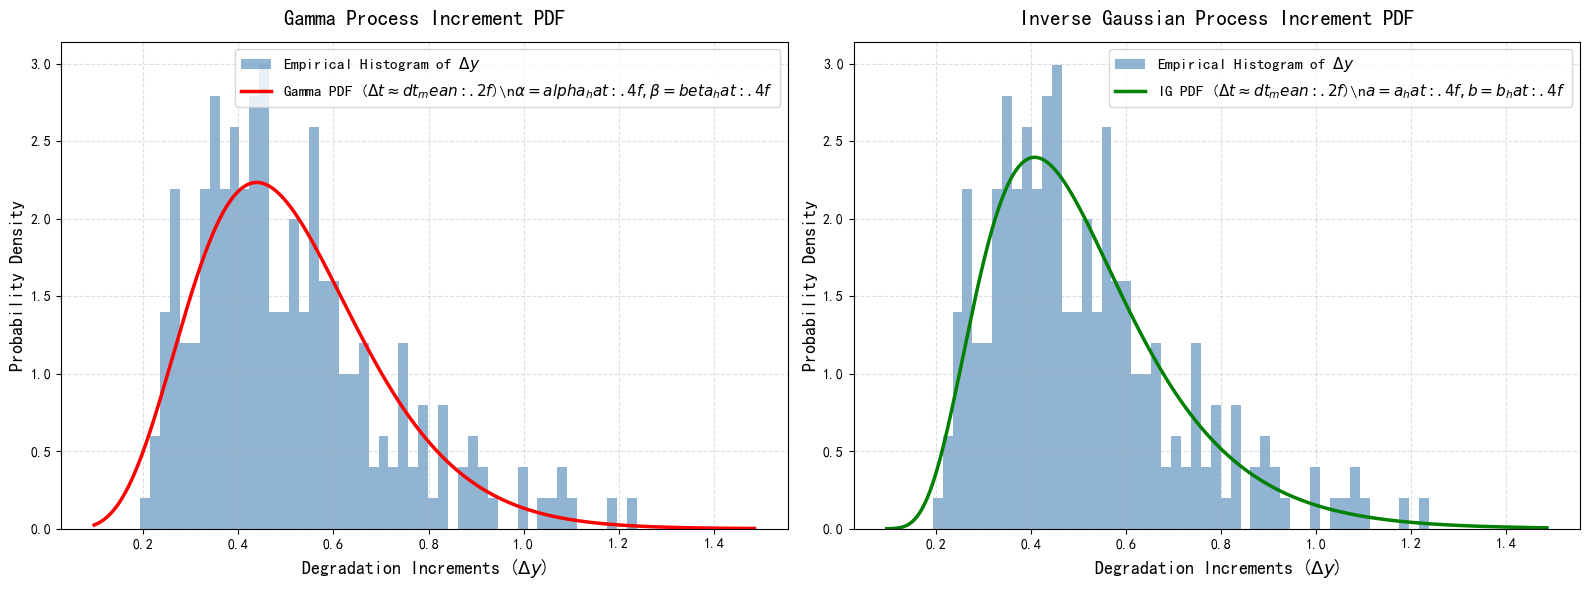

In [23]:
# ================================================================
# Plot the PDF of the increments based on Gamma and IG processes
# with the histogram of actual degradation data increments.
# ================================================================
import scipy.stats as stats
import matplotlib.pyplot as plt

dt_mean = np.mean(dt_pos)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_range = np.linspace(max(1e-6, dy_pos.min() * 0.5), dy_pos.max() * 1.2, 500)

# --- 1. Gamma Process Increment PDF ---
ax1 = axes[0]
ax1.hist(dy_pos, bins=50, density=True, alpha=0.6, color='steelblue', label=r'Empirical Histogram of $\Delta y$')

# Gamma 分布在 scipy.stats.gamma 形参为 a=shape, scale=beta
pdf_gamma_inc = stats.gamma.pdf(y_range, a=alpha_hat * dt_mean, scale=beta_hat)
ax1.plot(y_range, pdf_gamma_inc, 'r-', linewidth=2.5, 
         label=r'Gamma PDF ($\Delta t \approx {dt_mean:.2f}$)\n$\alpha={alpha_hat:.4f}, \beta={beta_hat:.4f}$')
ax1.set_title('Gamma Process Increment PDF', fontsize=15, fontweight='bold', pad=12)
ax1.set_xlabel(r'Degradation Increments ($\Delta y$)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- 2. Inverse Gaussian Process Increment PDF ---
ax2 = axes[1]
ax2.hist(dy_pos, bins=50, density=True, alpha=0.6, color='steelblue', label=r'Empirical Histogram of $\Delta y$')

# IG 分布在 scipy.stats.invgauss 形参比较特殊:
# 真实参数 mu_ig, lambda_ig
# scipy 的 mu = mu_ig / lambda_ig; scale = lambda_ig
# 我们的是 mu_ig = a*dt, lambda_ig = b*dt^2
scipy_mu = (a_hat * dt_mean) / (b_hat * dt_mean**2)
scipy_scale = b_hat * dt_mean**2
pdf_ig_inc = stats.invgauss.pdf(y_range, mu=scipy_mu, scale=scipy_scale)
ax2.plot(y_range, pdf_ig_inc, 'g-', linewidth=2.5, 
         label=r'IG PDF ($\Delta t \approx {dt_mean:.2f}$)\n$a={a_hat:.4f}, b={b_hat:.4f}$')
ax2.set_title('Inverse Gaussian Process Increment PDF', fontsize=15, fontweight='bold', pad=12)
ax2.set_xlabel(r'Degradation Increments ($\Delta y$)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig('Increments_PDF_Gamma_IG.pdf', bbox_inches='tight')
fig.savefig('Increments_PDF_Gamma_IG.svg', bbox_inches='tight')
plt.show()


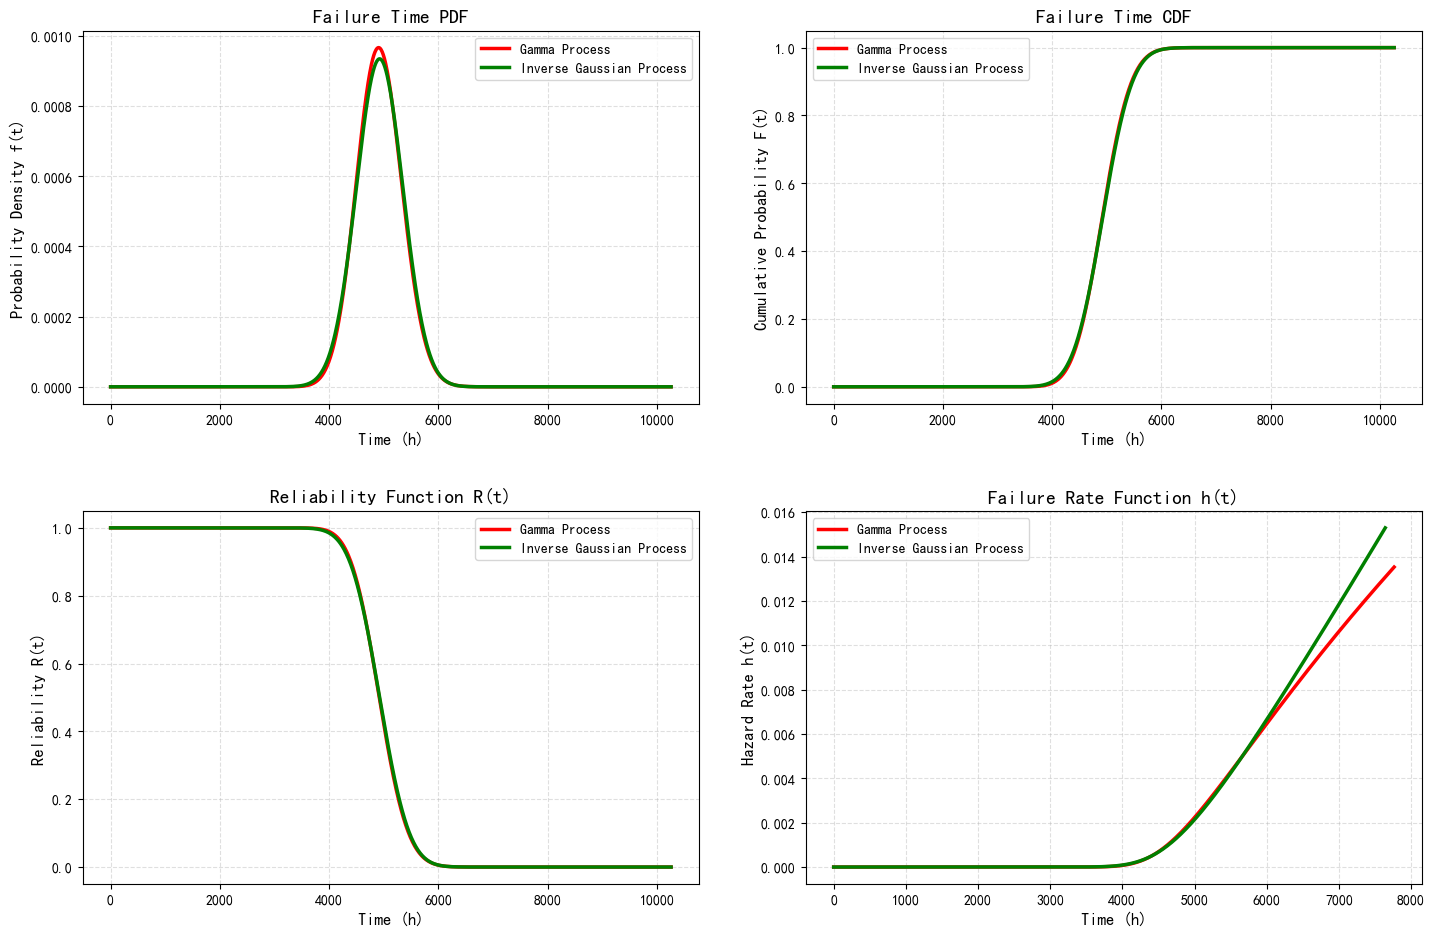

Median Life (50% Reliability Time) Estimation:
  Gamma Process            : 4918.57 h
  Inverse Gaussian Process : 4925.58 h


In [24]:
# ================================================================
# First Hitting Time (Failure Time) Distributions 
# based on Gamma Process and Inverse Gaussian Process
# ================================================================
from scipy.optimize import root_scalar

# 时间序列 (用作画图)
t_plot = np.linspace(1, ttf_data.max() * 1.5, 1000)

# --- Gamma 过程失效时间评估 ---
# 因为路程是单调非减的，所以 P(T <= t) = P(Y(t) >= L) 
# F(t) = 1 - CDF_{Y(t)}(L)
cdf_gamma = 1.0 - stats.gamma.cdf(threshold, a=alpha_hat * t_plot, scale=beta_hat)
# 使用数值梯度来计算 PDF (d F(t) / dt)
pdf_gamma = np.gradient(cdf_gamma, t_plot)
rel_gamma = 1.0 - cdf_gamma
haz_gamma = pdf_gamma / np.where(rel_gamma > 1e-10, rel_gamma, np.nan)

# --- Inverse Gaussian 过程失效时间评估 ---
scipy_mu_arr = (a_hat * t_plot) / (b_hat * t_plot**2)
scipy_scale_arr = b_hat * t_plot**2
cdf_ig = 1.0 - stats.invgauss.cdf(threshold, mu=scipy_mu_arr, scale=scipy_scale_arr)
pdf_ig = np.gradient(cdf_ig, t_plot)
rel_ig = 1.0 - cdf_ig
haz_ig = pdf_ig / np.where(rel_ig > 1e-10, rel_ig, np.nan)

# ----------------------------------------------------------------
# 绘图: PDF, CDF, Reliability, FRF
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# PDF
axes[0, 0].plot(t_plot, pdf_gamma, 'r-', linewidth=2.5, label='Gamma Process')
axes[0, 0].plot(t_plot, pdf_ig, 'g-', linewidth=2.5, label='Inverse Gaussian Process')
axes[0, 0].set_title('Failure Time PDF', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Time (h)', fontsize=12)
axes[0, 0].set_ylabel('Probability Density f(t)', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.4)

# CDF
axes[0, 1].plot(t_plot, cdf_gamma, 'r-', linewidth=2.5, label='Gamma Process')
axes[0, 1].plot(t_plot, cdf_ig, 'g-', linewidth=2.5, label='Inverse Gaussian Process')
axes[0, 1].set_title('Failure Time CDF', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Time (h)', fontsize=12)
axes[0, 1].set_ylabel('Cumulative Probability F(t)', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

# Reliability
axes[1, 0].plot(t_plot, rel_gamma, 'r-', linewidth=2.5, label='Gamma Process')
axes[1, 0].plot(t_plot, rel_ig, 'g-', linewidth=2.5, label='Inverse Gaussian Process')
axes[1, 0].set_title('Reliability Function R(t)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Time (h)', fontsize=12)
axes[1, 0].set_ylabel('Reliability R(t)', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

# Hazard Rate
axes[1, 1].plot(t_plot, haz_gamma, 'r-', linewidth=2.5, label='Gamma Process')
axes[1, 1].plot(t_plot, haz_ig, 'g-', linewidth=2.5, label='Inverse Gaussian Process')
axes[1, 1].set_title('Failure Rate Function h(t)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time (h)', fontsize=12)
axes[1, 1].set_ylabel('Hazard Rate h(t)', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(pad=3.0)
fig.savefig('Failure_Time_Functions_Gamma_IG.pdf', bbox_inches='tight')
fig.savefig('Failure_Time_Functions_Gamma_IG.svg', bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 计算中位寿命 (Median Life) - 使用 Brentq 寻根方程 F(t) - 0.5 = 0
# ----------------------------------------------------------------
def root_gamma(t):
    return (1.0 - stats.gamma.cdf(threshold, a=alpha_hat * t, scale=beta_hat)) - 0.5

def root_ig(t):
    scipy_m = (a_hat * t) / (b_hat * t**2)
    scipy_s = b_hat * t**2
    return (1.0 - stats.invgauss.cdf(threshold, mu=scipy_m, scale=scipy_s)) - 0.5

t_high = ttf_data.max() * 10
try:
    # 寻找 F(t) - 0.5 = 0 的根
    res_gamma = root_scalar(root_gamma, bracket=[1e-5, t_high], method='brentq')
    median_gamma = res_gamma.root
except Exception as e:
    median_gamma = np.nan
    print(f'Error calculating Gamma Process Median Life: {e}')
    
try:
    # 寻找 F(t) - 0.5 = 0 的根
    res_ig = root_scalar(root_ig, bracket=[1e-5, t_high], method='brentq')
    median_ig = res_ig.root
except Exception as e:
    median_ig = np.nan
    print(f'Error calculating IG Process Median Life: {e}')

print('=' * 80)
print('Median Life (50% Reliability Time) Estimation:')
print(f'  Gamma Process            : {median_gamma:.2f} h')
print(f'  Inverse Gaussian Process : {median_ig:.2f} h')
print('=' * 80)


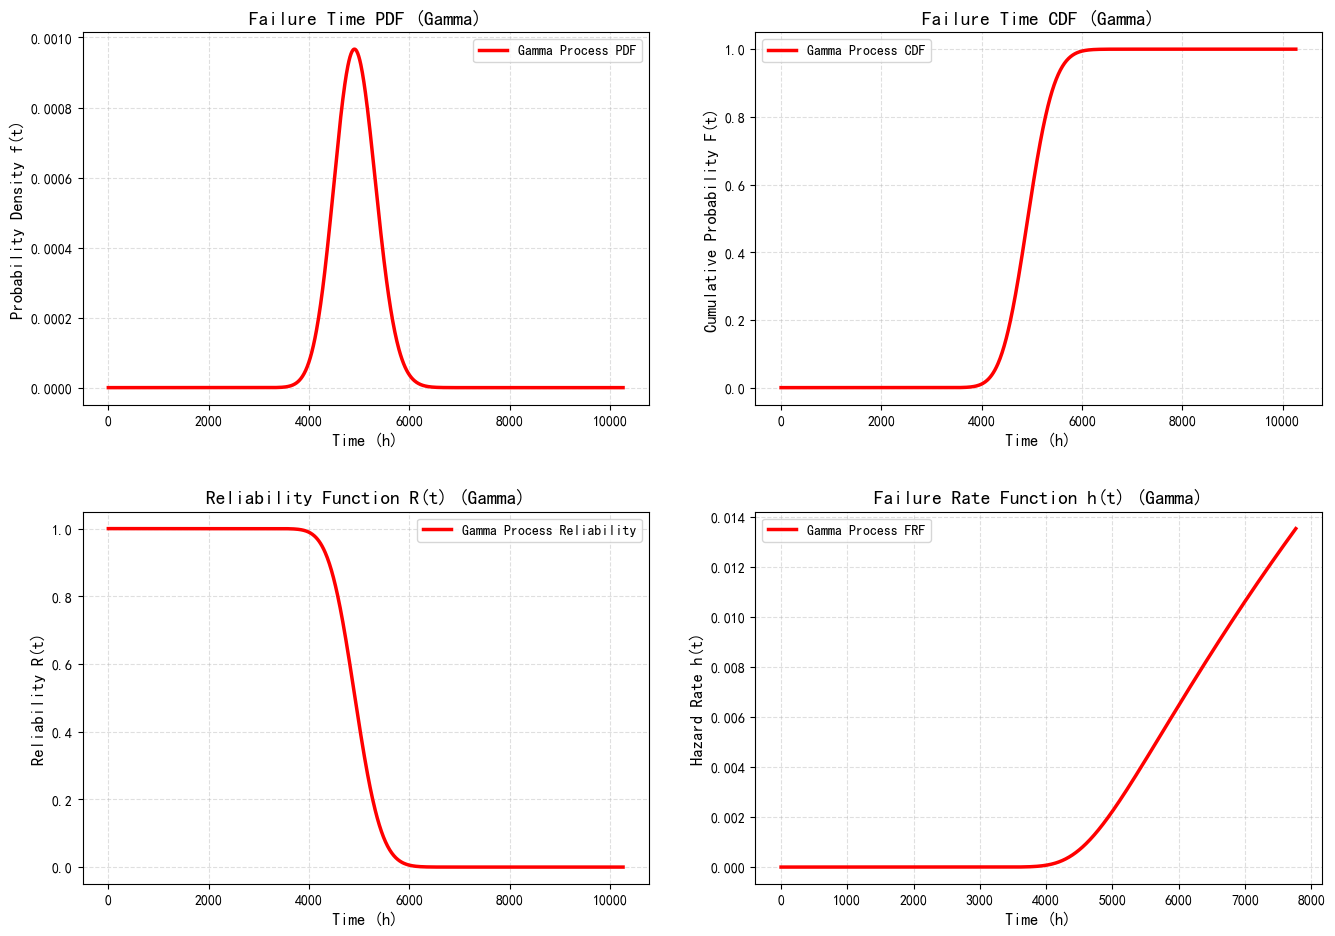

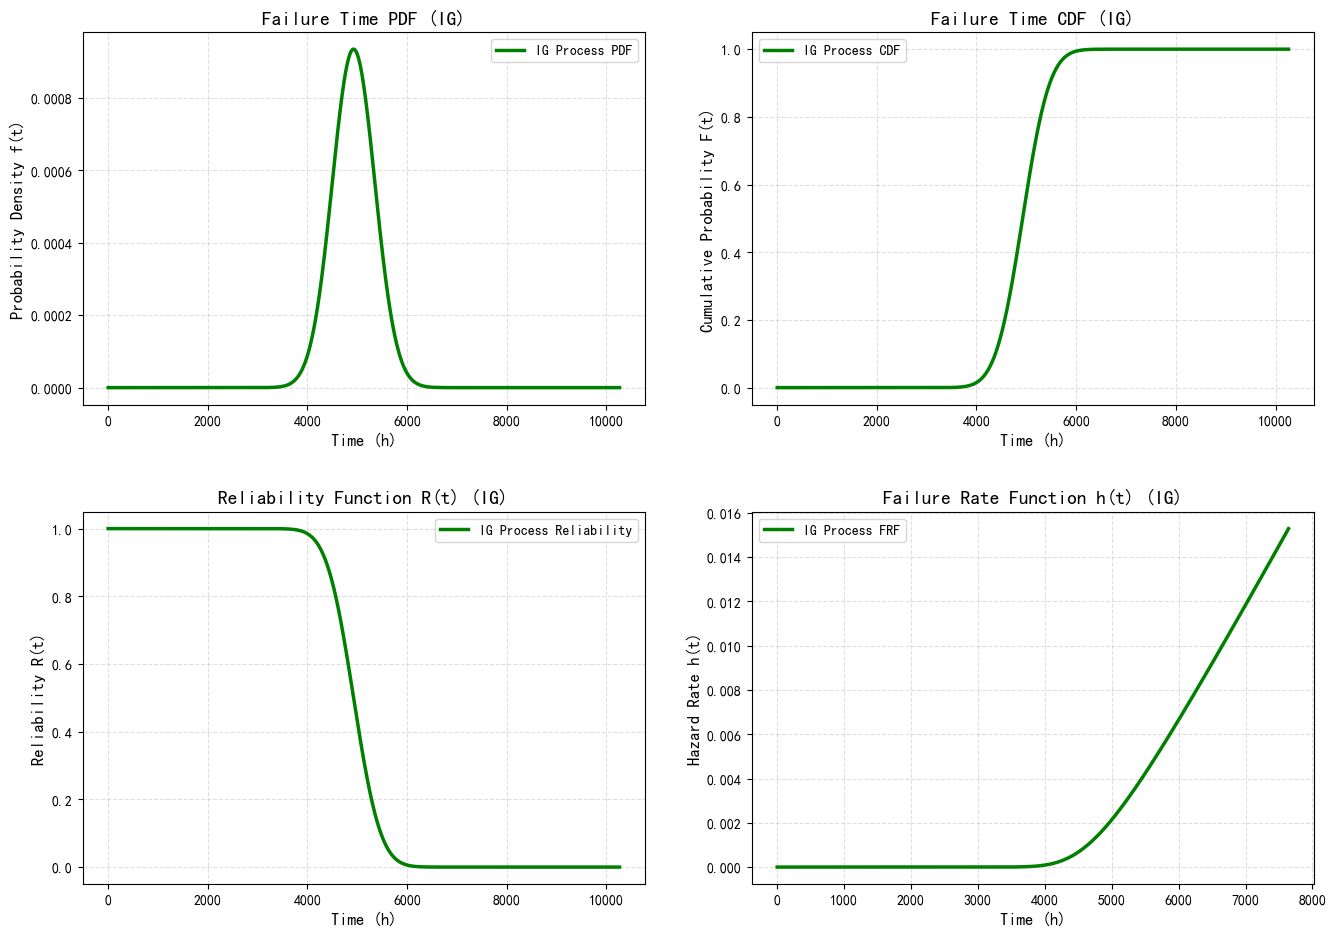

Median Life (50% Reliability Time) Estimation:
  Gamma Process            : 4918.57 h
  Inverse Gaussian Process : 4925.58 h


In [25]:
# ================================================================
# First Hitting Time (Failure Time) Distributions 
# based on Gamma Process and Inverse Gaussian Process
# ================================================================
from scipy.optimize import root_scalar

# 时间序列 (用作画图)
t_plot = np.linspace(1, ttf_data.max() * 1.5, 1000)

# --- Gamma 过程失效时间评估 ---
# 因为路程是单调非减的，所以 P(T <= t) = P(Y(t) >= L) 
# F(t) = 1 - CDF_{Y(t)}(L)
cdf_gamma = 1.0 - stats.gamma.cdf(threshold, a=alpha_hat * t_plot, scale=beta_hat)
# 使用数值梯度来计算 PDF (d F(t) / dt)
pdf_gamma = np.gradient(cdf_gamma, t_plot)
rel_gamma = 1.0 - cdf_gamma
haz_gamma = pdf_gamma / np.where(rel_gamma > 1e-10, rel_gamma, np.nan)

# --- Inverse Gaussian 过程失效时间评估 ---
scipy_mu_arr = (a_hat * t_plot) / (b_hat * t_plot**2)
scipy_scale_arr = b_hat * t_plot**2
cdf_ig = 1.0 - stats.invgauss.cdf(threshold, mu=scipy_mu_arr, scale=scipy_scale_arr)
pdf_ig = np.gradient(cdf_ig, t_plot)
rel_ig = 1.0 - cdf_ig
haz_ig = pdf_ig / np.where(rel_ig > 1e-10, rel_ig, np.nan)

# ----------------------------------------------------------------
# 绘图: Gamma Process - PDF, CDF, Reliability, FRF
# ----------------------------------------------------------------
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))

# PDF
axes1[0, 0].plot(t_plot, pdf_gamma, 'r-', linewidth=2.5, label='Gamma Process PDF')
axes1[0, 0].set_title('Failure Time PDF (Gamma)', fontsize=14, fontweight='bold')
axes1[0, 0].set_xlabel('Time (h)', fontsize=12)
axes1[0, 0].set_ylabel('Probability Density f(t)', fontsize=12)
axes1[0, 0].legend()
axes1[0, 0].grid(True, linestyle='--', alpha=0.4)

# CDF
axes1[0, 1].plot(t_plot, cdf_gamma, 'r-', linewidth=2.5, label='Gamma Process CDF')
axes1[0, 1].set_title('Failure Time CDF (Gamma)', fontsize=14, fontweight='bold')
axes1[0, 1].set_xlabel('Time (h)', fontsize=12)
axes1[0, 1].set_ylabel('Cumulative Probability F(t)', fontsize=12)
axes1[0, 1].legend()
axes1[0, 1].grid(True, linestyle='--', alpha=0.4)

# Reliability
axes1[1, 0].plot(t_plot, rel_gamma, 'r-', linewidth=2.5, label='Gamma Process Reliability')
axes1[1, 0].set_title('Reliability Function R(t) (Gamma)', fontsize=14, fontweight='bold')
axes1[1, 0].set_xlabel('Time (h)', fontsize=12)
axes1[1, 0].set_ylabel('Reliability R(t)', fontsize=12)
axes1[1, 0].legend()
axes1[1, 0].grid(True, linestyle='--', alpha=0.4)

# Hazard Rate
axes1[1, 1].plot(t_plot, haz_gamma, 'r-', linewidth=2.5, label='Gamma Process FRF')
axes1[1, 1].set_title('Failure Rate Function h(t) (Gamma)', fontsize=14, fontweight='bold')
axes1[1, 1].set_xlabel('Time (h)', fontsize=12)
axes1[1, 1].set_ylabel('Hazard Rate h(t)', fontsize=12)
axes1[1, 1].legend()
axes1[1, 1].grid(True, linestyle='--', alpha=0.4)

fig1.tight_layout(pad=3.0)
fig1.savefig('Failure_Time_Functions_Gamma.pdf', bbox_inches='tight')
fig1.savefig('Failure_Time_Functions_Gamma.svg', bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 绘图: Inverse Gaussian Process - PDF, CDF, Reliability, FRF
# ----------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))

# PDF
axes2[0, 0].plot(t_plot, pdf_ig, 'g-', linewidth=2.5, label='IG Process PDF')
axes2[0, 0].set_title('Failure Time PDF (IG)', fontsize=14, fontweight='bold')
axes2[0, 0].set_xlabel('Time (h)', fontsize=12)
axes2[0, 0].set_ylabel('Probability Density f(t)', fontsize=12)
axes2[0, 0].legend()
axes2[0, 0].grid(True, linestyle='--', alpha=0.4)

# CDF
axes2[0, 1].plot(t_plot, cdf_ig, 'g-', linewidth=2.5, label='IG Process CDF')
axes2[0, 1].set_title('Failure Time CDF (IG)', fontsize=14, fontweight='bold')
axes2[0, 1].set_xlabel('Time (h)', fontsize=12)
axes2[0, 1].set_ylabel('Cumulative Probability F(t)', fontsize=12)
axes2[0, 1].legend()
axes2[0, 1].grid(True, linestyle='--', alpha=0.4)

# Reliability
axes2[1, 0].plot(t_plot, rel_ig, 'g-', linewidth=2.5, label='IG Process Reliability')
axes2[1, 0].set_title('Reliability Function R(t) (IG)', fontsize=14, fontweight='bold')
axes2[1, 0].set_xlabel('Time (h)', fontsize=12)
axes2[1, 0].set_ylabel('Reliability R(t)', fontsize=12)
axes2[1, 0].legend()
axes2[1, 0].grid(True, linestyle='--', alpha=0.4)

# Hazard Rate
axes2[1, 1].plot(t_plot, haz_ig, 'g-', linewidth=2.5, label='IG Process FRF')
axes2[1, 1].set_title('Failure Rate Function h(t) (IG)', fontsize=14, fontweight='bold')
axes2[1, 1].set_xlabel('Time (h)', fontsize=12)
axes2[1, 1].set_ylabel('Hazard Rate h(t)', fontsize=12)
axes2[1, 1].legend()
axes2[1, 1].grid(True, linestyle='--', alpha=0.4)

fig2.tight_layout(pad=3.0)
fig2.savefig('Failure_Time_Functions_IG.pdf', bbox_inches='tight')
fig2.savefig('Failure_Time_Functions_IG.svg', bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 计算中位寿命 (Median Life) - 使用 Brentq 寻根方程 F(t) - 0.5 = 0
# ----------------------------------------------------------------
def root_gamma(t):
    return (1.0 - stats.gamma.cdf(threshold, a=alpha_hat * t, scale=beta_hat)) - 0.5

def root_ig(t):
    scipy_m = (a_hat * t) / (b_hat * t**2)
    scipy_s = b_hat * t**2
    return (1.0 - stats.invgauss.cdf(threshold, mu=scipy_m, scale=scipy_s)) - 0.5

t_high = ttf_data.max() * 10
try:
    # 寻找 F(t) - 0.5 = 0 的根
    res_gamma = root_scalar(root_gamma, bracket=[1e-5, t_high], method='brentq')
    median_gamma = res_gamma.root
except Exception as e:
    median_gamma = np.nan
    print(f'Error calculating Gamma Process Median Life: {e}')
    
try:
    # 寻找 F(t) - 0.5 = 0 的根
    res_ig = root_scalar(root_ig, bracket=[1e-5, t_high], method='brentq')
    median_ig = res_ig.root
except Exception as e:
    median_ig = np.nan
    print(f'Error calculating IG Process Median Life: {e}')

print('=' * 80)
print('Median Life (50% Reliability Time) Estimation:')
print(f'  Gamma Process            : {median_gamma:.2f} h')
print(f'  Inverse Gaussian Process : {median_ig:.2f} h')
print('=' * 80)


In [26]:
# ================================================================
# Random-Effects Gamma Process MLE (Conjugate Prior)
# Latent parameter beta_i (scale) ~ InverseGamma(epsilon, gamma)
# equivalently, rate 1/beta_i ~ Gamma(shape=epsilon, rate=gamma)
# 这是标准的具备共轭解的退化分布模型，通过直接最大化边际似然求出参数
# ================================================================
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. 整理各单元增量数据 (由于 Gamma 过程无负增量，这里仅过滤严格为正的值)
unit_data = []
for i, unit in enumerate(units_arr):
    t_data = time_arr[i]
    y_data = current_arr[i]
    valid = ~np.isnan(t_data) & ~np.isnan(y_data)
    t_data = t_data[valid].astype(float)
    y_data = y_data[valid].astype(float)
    
    sort_idx = np.argsort(t_data)
    t_data = t_data[sort_idx]
    y_data = y_data[sort_idx]
    
    dt = np.diff(t_data)
    dy = np.diff(y_data)
    valid_diff = (dt > 0) & (dy > 0)
    dt = dt[valid_diff]
    dy = dy[valid_diff]
    if len(dt) > 0:
        unit_data.append({'Unit': unit, 'dy': dy, 'dt': dt, 
                          'Y_i': np.sum(dy), 'T_i': np.sum(dt)})

# 2. 共轭先验边缘对数似然 (Negative Log Marginal Likelihood)
def neg_log_marginal_likelihood(params):
    alpha, eps, gamma_prior = params[0], params[1], params[2]
    if alpha <= 1e-6 or eps <= 1e-6 or gamma_prior <= 1e-6:
        return 1e10
    ll = 0.0
    for d in unit_data:
        dy, dt = d['dy'], d['dt']
        Y_i, T_i = d['Y_i'], d['T_i']
        
        # 积分后得到无潜变量的边际对数似然项
        term1 = np.sum((alpha * dt - 1) * np.log(dy) - gammaln(alpha * dt))
        term2 = eps * np.log(gamma_prior) - gammaln(eps)
        term3 = gammaln(alpha * T_i + eps) - (alpha * T_i + eps) * np.log(Y_i + gamma_prior)
        ll += term1 + term2 + term3
        
    if not np.isfinite(ll):
        return 1e10
    return -ll

# 3. 利用矩估计获取较佳的初始数值以帮助收敛
pos_dy = all_dy[all_dy > 0]
pos_dt = all_dt[all_dy > 0]
mean_rate = np.mean(pos_dy / pos_dt)
var_rate = np.var(pos_dy / pos_dt)
beta_guess = var_rate / mean_rate
alpha0 = mean_rate / beta_guess

beta_i_est = [ (d['Y_i'] / d['T_i']) / alpha0 for d in unit_data ]
mean_beta = np.mean(beta_i_est)
var_beta = np.var(beta_i_est)
eps0 = (mean_beta**2) / max(var_beta, 1e-5) + 2.0
gamma0 = mean_beta * (eps0 - 1.0)
x0 = [max(1e-3, alpha0), max(1e-3, eps0), max(1e-3, gamma0)]

# 4. 执行优化寻找 MLE 参数
res_re_gamma = minimize(neg_log_marginal_likelihood, x0=x0, 
                        bounds=[(1e-5, None), (1e-5, None), (1e-5, None)], 
                        method='L-BFGS-B')
alpha_re, eps_re, gamma_re = res_re_gamma.x

# 打印结果
print('=' * 80)
print('Hierarchical Gamma Process MLE Parameters (Conjugate Random Effect):')
print(f'  Shape parameter rate (alpha)    = {alpha_re:.6e}')
print(f'  Prior shape for Latent beta (eps) = {eps_re:.6e}')
print(f'  Prior scale for Latent beta (gam) = {gamma_re:.6e}')
print('=' * 80)


Hierarchical Gamma Process MLE Parameters (Conjugate Random Effect):
  Shape parameter rate (alpha)    = 3.905973e-02
  Prior shape for Latent beta (eps) = 2.892961e+01
  Prior scale for Latent beta (gam) = 1.455415e+00


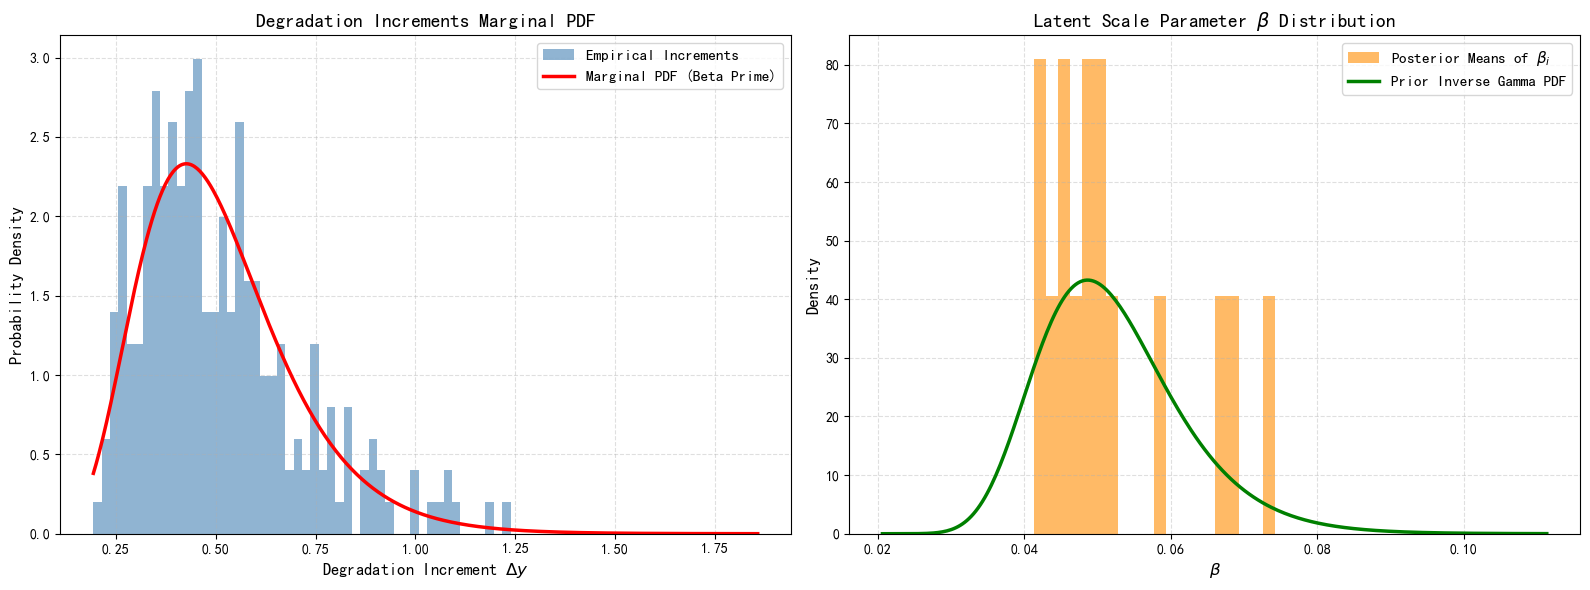

In [27]:
# ================================================================
# 绘制增量边际分布，以及潜变量 Beta 的先验和后验期望分布对比图
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. Increment Marginal PDF vs Degradation Increment Histogram ---
ax1 = axes[0]
dy_valid = all_dy[all_dy > 0]
ax1.hist(dy_valid, bins=50, density=True, alpha=0.6, color='steelblue', label='Empirical Increments')

# 对于尺度参数 Inverse Gamma 先验的 Gamma 增量分布，其边际增量理论分布属于 BetaPrime 族
dt_mean_pos = np.mean(all_dt[all_dy > 0])
y_range = np.linspace(dy_valid.min(), dy_valid.max() * 1.5, 500)
pdf_inc = stats.betaprime.pdf(y_range, a=alpha_re * dt_mean_pos, b=eps_re, scale=gamma_re)
ax1.plot(y_range, pdf_inc, 'r-', linewidth=2.5, label='Marginal PDF (Beta Prime)')
ax1.set_title('Degradation Increments Marginal PDF', fontsize=14, fontweight='bold')
ax1.set_xlabel(r'Degradation Increment $\Delta y$', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- 2. Prior latent beta vs Posterior mean beta histogram ---
ax2 = axes[1]
# 各测试单元各自由于共轭性导致的后验期望值: E[beta_i | Data] = (Y_i + gamma) / (alpha * T_i + eps - 1)  ; if denom > 0
beta_post_means = []
for d in unit_data:
    denom = alpha_re * d['T_i'] + eps_re - 1.0
    if denom > 0:
        beta_post_means.append((d['Y_i'] + gamma_re) / denom)
beta_post_means = np.array(beta_post_means)

ax2.hist(beta_post_means, bins=20, density=True, alpha=0.6, color='darkorange', label=r'Posterior Means of $\beta_i$')

# 理论 Inverse Gamma 先验
if len(beta_post_means) > 0:
    b_range = np.linspace(max(1e-6, beta_post_means.min() * 0.5), beta_post_means.max() * 1.5, 300)
else:
    b_range = np.linspace(1e-6, 1.0, 300)
    
prior_pdf = stats.invgamma.pdf(b_range, a=eps_re, scale=gamma_re)
ax2.plot(b_range, prior_pdf, 'g-', linewidth=2.5, label='Prior Inverse Gamma PDF')
ax2.set_title(r'Latent Scale Parameter $\beta$ Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel(r'$\beta$', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig('RE_Gamma_Increments_and_Beta.svg', bbox_inches='tight')
fig.savefig('RE_Gamma_Increments_and_Beta.pdf', bbox_inches='tight')
plt.show()


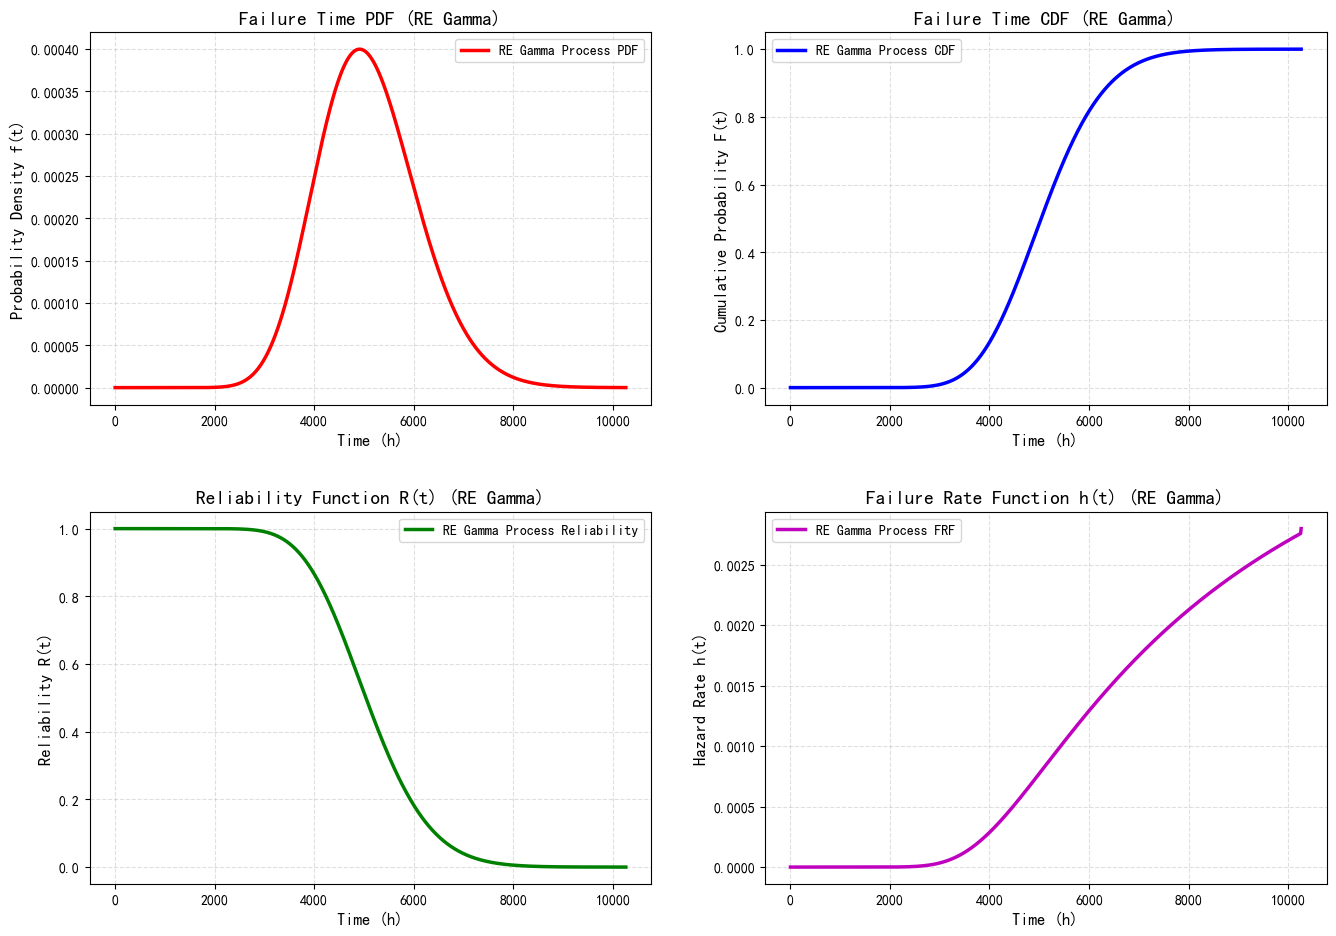


********************************************************************************
  Median Life of Hierarchical (RE) Gamma Process Model: 5038.95 h
********************************************************************************



In [28]:
# ================================================================
# Failure Time (Life) Functions based on Hierarchical Gamma Process
# PDF, CDF, Reliability, FRF & Median Life Computation
# ================================================================
from scipy.optimize import root_scalar

t_plot_re = np.linspace(1, ttf_data.max() * 1.5, 1000)

# 总体单调随机变量的可靠度可通过求解特定状态的不完全 Beta 概率来实现:
# R(t) = P(T > t) = P(Y(t) < L) = beta.cdf( L / (L + gamma), a = alpha * t, b = eps )
rel_re = stats.beta.cdf(threshold / (threshold + gamma_re), a=alpha_re * t_plot_re, b=eps_re)
cdf_re = 1.0 - rel_re
pdf_re = np.gradient(cdf_re, t_plot_re)
haz_re = pdf_re / np.where(rel_re > 1e-10, rel_re, np.nan)

# ----------------------------------------------------------------
# 1. 画 4 张独立特征图
# ----------------------------------------------------------------
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
ax_pdf, ax_cdf, ax_rel, ax_haz = axes3.flatten()

ax_pdf.plot(t_plot_re, pdf_re, 'r-', linewidth=2.5, label='RE Gamma Process PDF')
ax_pdf.set_title('Failure Time PDF (RE Gamma)', fontsize=14, fontweight='bold')
ax_pdf.set_xlabel('Time (h)', fontsize=12)
ax_pdf.set_ylabel('Probability Density f(t)', fontsize=12)
ax_pdf.legend()
ax_pdf.grid(True, linestyle='--', alpha=0.4)

ax_cdf.plot(t_plot_re, cdf_re, 'b-', linewidth=2.5, label='RE Gamma Process CDF')
ax_cdf.set_title('Failure Time CDF (RE Gamma)', fontsize=14, fontweight='bold')
ax_cdf.set_xlabel('Time (h)', fontsize=12)
ax_cdf.set_ylabel('Cumulative Probability F(t)', fontsize=12)
ax_cdf.legend()
ax_cdf.grid(True, linestyle='--', alpha=0.4)

ax_rel.plot(t_plot_re, rel_re, 'g-', linewidth=2.5, label='RE Gamma Process Reliability')
ax_rel.set_title('Reliability Function R(t) (RE Gamma)', fontsize=14, fontweight='bold')
ax_rel.set_xlabel('Time (h)', fontsize=12)
ax_rel.set_ylabel('Reliability R(t)', fontsize=12)
ax_rel.legend()
ax_rel.grid(True, linestyle='--', alpha=0.4)

ax_haz.plot(t_plot_re, haz_re, 'm-', linewidth=2.5, label='RE Gamma Process FRF')
ax_haz.set_title('Failure Rate Function h(t) (RE Gamma)', fontsize=14, fontweight='bold')
ax_haz.set_xlabel('Time (h)', fontsize=12)
ax_haz.set_ylabel('Hazard Rate h(t)', fontsize=12)
ax_haz.legend()
ax_haz.grid(True, linestyle='--', alpha=0.4)

fig3.tight_layout(pad=3.0)
fig3.savefig('Failure_Time_Functions_RE_Gamma.svg', bbox_inches='tight')
fig3.savefig('Failure_Time_Functions_RE_Gamma.pdf', bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 2. 求中位寿命 (Median Life) 打印结果
# ----------------------------------------------------------------
def root_func_re(t):
    return (1.0 - stats.beta.cdf(threshold / (threshold + gamma_re), a=alpha_re * t, b=eps_re)) - 0.5

t_high = ttf_data.max() * 10
try:
    res_re = root_scalar(root_func_re, bracket=[1e-5, t_high], method='brentq')
    median_re = res_re.root
    
    print('\n' + '*' * 80)
    print(f'  Median Life of Hierarchical (RE) Gamma Process Model: {median_re:.2f} h')
    print('*' * 80 + '\n')
except Exception as e:
    print(f'Error computing median life for RE Gamma: {e}')


In [29]:
# ================================================================
# Model Assessment and Comparison based on Degradation Increments
# AIC, BIC, and Log-likelihood of Wienger, Pure Gamma, 
# Inverse Gaussian, and RE-Gamma processes.
# Followed by a comparison of their respective Median Lives.
# ================================================================
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import root_scalar

# --- 1. 计算各个模型的对数似然 (Log-Likelihood) ---
# Wiener Process (num_params = 2: mu, sigma2)
LL_wiener = np.sum(stats.norm.logpdf(all_dy, loc=mu_global * all_dt, scale=np.sqrt(sigma2_global * all_dt)))
k_wiener = 2
n_wiener = len(all_dy)

# Pure Gamma Process (num_params = 2: alpha, beta)
# 这里的增量必须使用 dy_pos, dt_pos
LL_gamma = np.sum(stats.gamma.logpdf(dy_pos, a=alpha_hat * dt_pos, scale=beta_hat))
k_gamma = 2
n_pos = len(dy_pos)

# Inverse Gaussian Process (num_params = 2: a, b)
scipy_m_inc = (a_hat * dt_pos) / (b_hat * dt_pos**2)
scipy_s_inc = b_hat * dt_pos**2
LL_ig = np.sum(stats.invgauss.logpdf(dy_pos, mu=scipy_m_inc, scale=scipy_s_inc))
k_ig = 2

# Gamma with Random Effects (Hierarchical Gamma) (num_params = 3: alpha, eps, gamma)
# 对数似然等于优化求解函数求出的最小值取反
LL_re_gamma = -res_re_gamma.fun
k_re_gamma = 3

# --- 2. 计算 AIC 与 BIC ---
# AIC = 2*k - 2*ln(L)
# BIC = k*ln(n) - 2*ln(L)
def calc_aic_bic(LL, k, n):
    return 2 * k - 2 * LL, k * np.log(n) - 2 * LL

aic_w, bic_w = calc_aic_bic(LL_wiener, k_wiener, n_wiener)
aic_g, bic_g = calc_aic_bic(LL_gamma, k_gamma, n_pos)
aic_ig, bic_ig = calc_aic_bic(LL_ig, k_ig, n_pos)
aic_reg, bic_reg = calc_aic_bic(LL_re_gamma, k_re_gamma, n_pos)

# --- 3. 汇总评价指标表 ---
df_eval = pd.DataFrame({
    'Model': ['Wiener Process', 'Pure Gamma', 'Inverse Gaussian', 'Gamma w/ Random Effects'],
    'Num_Params (k)': [k_wiener, k_gamma, k_ig, k_re_gamma],
    'Log-Likelihood': [LL_wiener, LL_gamma, LL_ig, LL_re_gamma],
    'AIC': [aic_w, aic_g, aic_ig, aic_reg],
    'BIC': [bic_w, bic_g, bic_ig, bic_reg]
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print('=' * 85)
print(' Model Assessment based on Degradation Data: Log-Likelihood, AIC, BIC')
print('=' * 85)
print(df_eval.round(4).to_string(index=False))
print('=' * 85)
df_eval.to_excel('Stochastic_Process_Models_Evaluation.xlsx', index=False)

# --- 4. 重新统一计算这四个模型的 Median Life (50% Reliability Time) ---
t_high = ttf_data.max() * 20

# Wiener Process Median Life 
def root_wp_func(t):
    return wp_cdf(t, mu_global, sigma2_global, threshold) - 0.5
try:
    ml_wp = root_scalar(root_wp_func, bracket=[1e-5, t_high], method='brentq').root
except:
    ml_wp = np.nan

# Pure Gamma Median Life
def root_gamma_func(t):
    return (1.0 - stats.gamma.cdf(threshold, a=alpha_hat * t, scale=beta_hat)) - 0.5
try:
    ml_gamma = root_scalar(root_gamma_func, bracket=[1e-5, t_high], method='brentq').root
except:
    ml_gamma = np.nan

# Inverse Gaussian Median Life
def root_ig_func(t):
    m = (a_hat * t) / (b_hat * t**2)
    s = b_hat * t**2
    return (1.0 - stats.invgauss.cdf(threshold, mu=m, scale=s)) - 0.5
try:
    ml_ig = root_scalar(root_ig_func, bracket=[1e-5, t_high], method='brentq').root
except:
    ml_ig = np.nan

# Gamma w/ Random Effects Median Life
def root_reg_func(t):
    return (1.0 - stats.beta.cdf(threshold / (threshold + gamma_re), a=alpha_re * t, b=eps_re)) - 0.5
try:
    ml_reg = root_scalar(root_reg_func, bracket=[1e-5, t_high], method='brentq').root
except:
    ml_reg = np.nan

print('\n' + '=' * 85)
print(' Median Life (50% Reliability Time / First Hitting Time) Comparison')
print('=' * 85)
print(f"  1. Wiener Process                : {ml_wp:.2f} h")
print(f"  2. Pure Gamma Process            : {ml_gamma:.2f} h")
print(f"  3. Inverse Gaussian Process      : {ml_ig:.2f} h")
print(f"  4. Gamma w/ Random Effects       : {ml_reg:.2f} h")
print('=' * 85)


 Model Assessment based on Degradation Data: Log-Likelihood, AIC, BIC
                  Model  Num_Params (k)  Log-Likelihood       AIC       BIC
         Wiener Process               2         45.5195  -87.0391  -80.0778
             Pure Gamma               2         69.6352 -135.2704 -128.3091
       Inverse Gaussian               2         75.1154 -146.2308 -139.2695
Gamma w/ Random Effects               3         93.7300 -181.4600 -171.0181

 Median Life (50% Reliability Time / First Hitting Time) Comparison
  1. Wiener Process                : 4887.79 h
  2. Pure Gamma Process            : 4918.57 h
  3. Inverse Gaussian Process      : 4925.58 h
  4. Gamma w/ Random Effects       : 5038.95 h


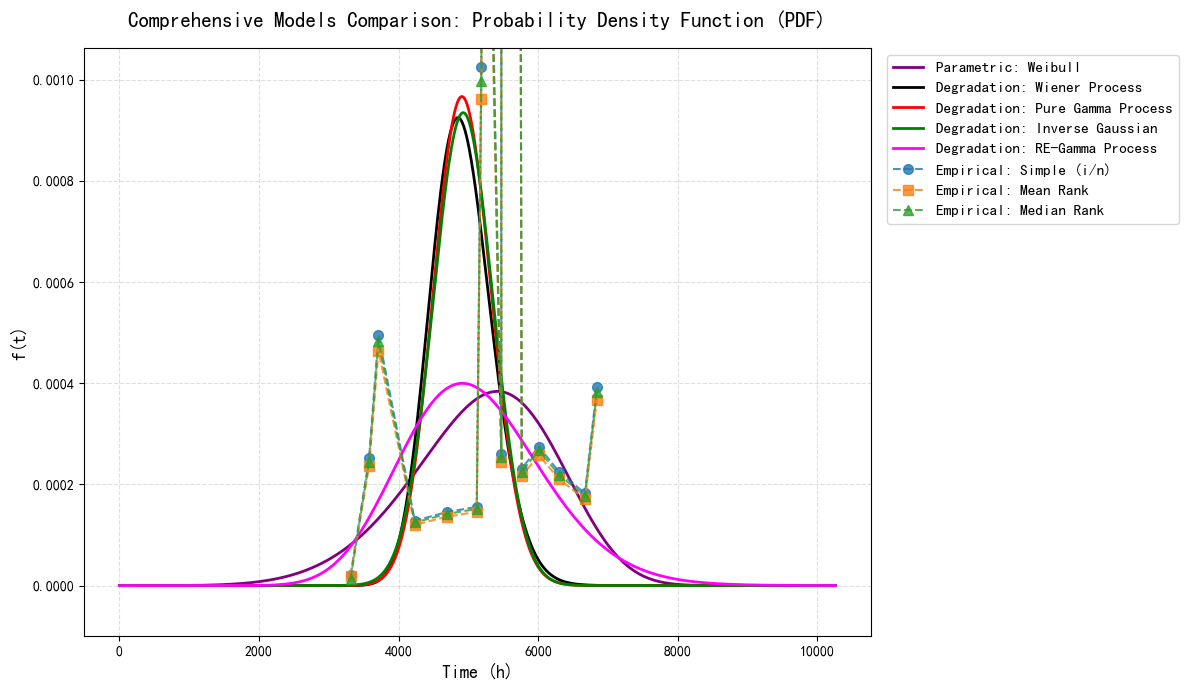

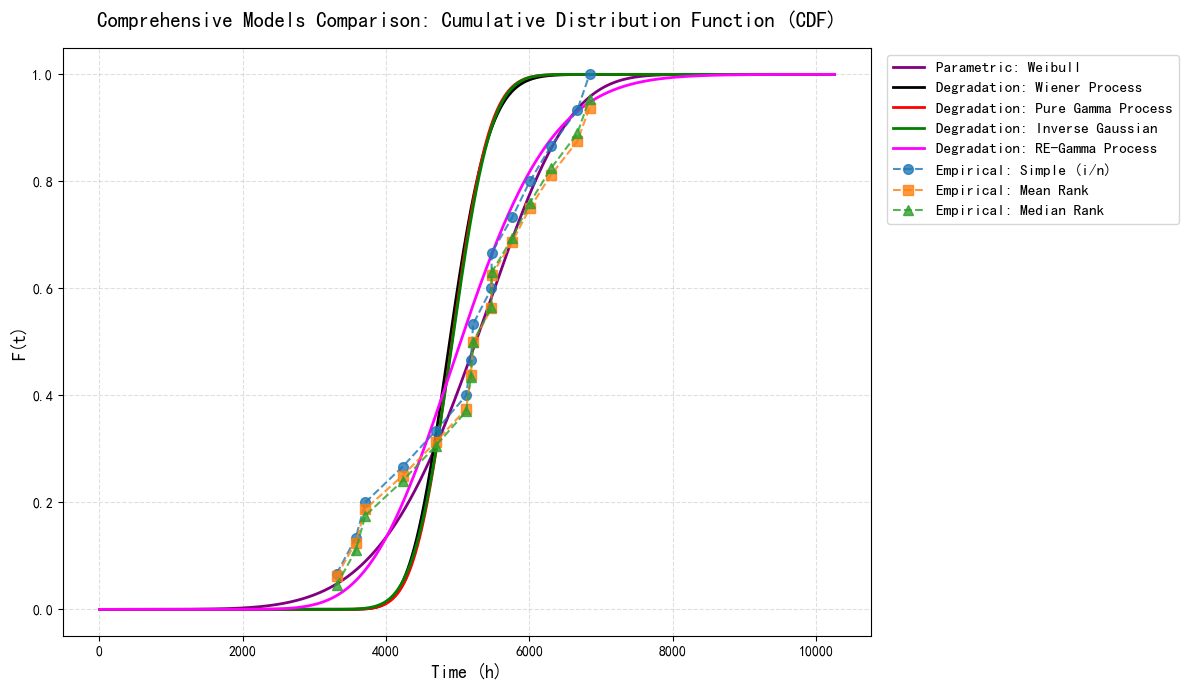

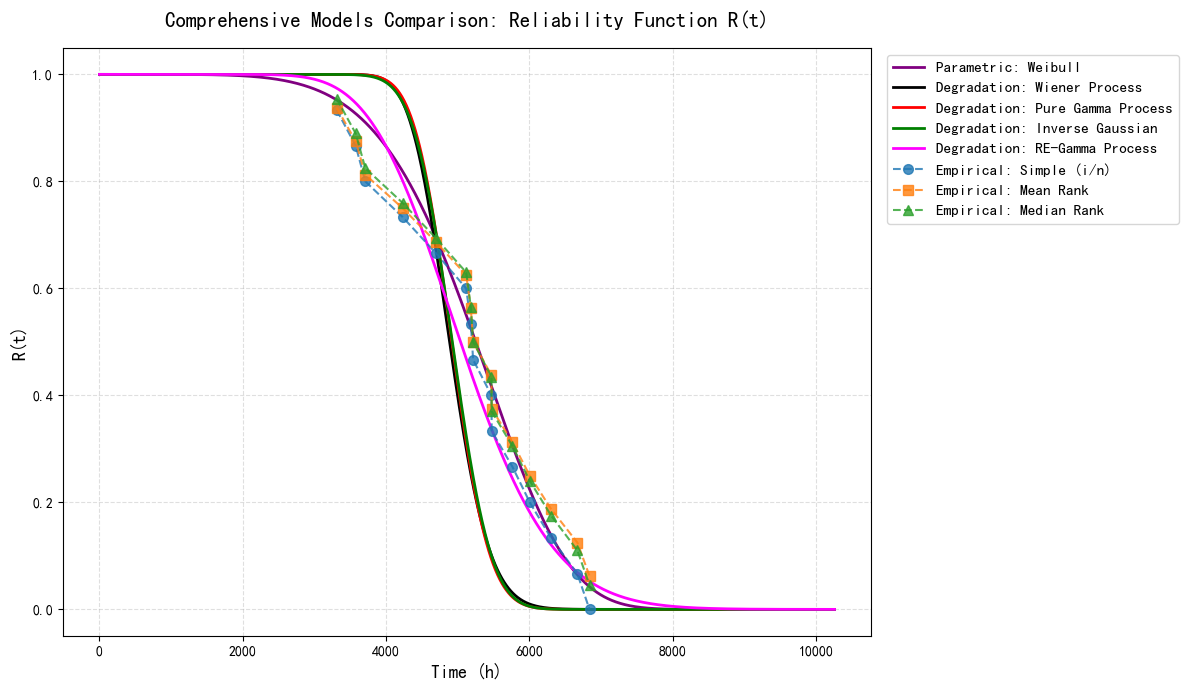

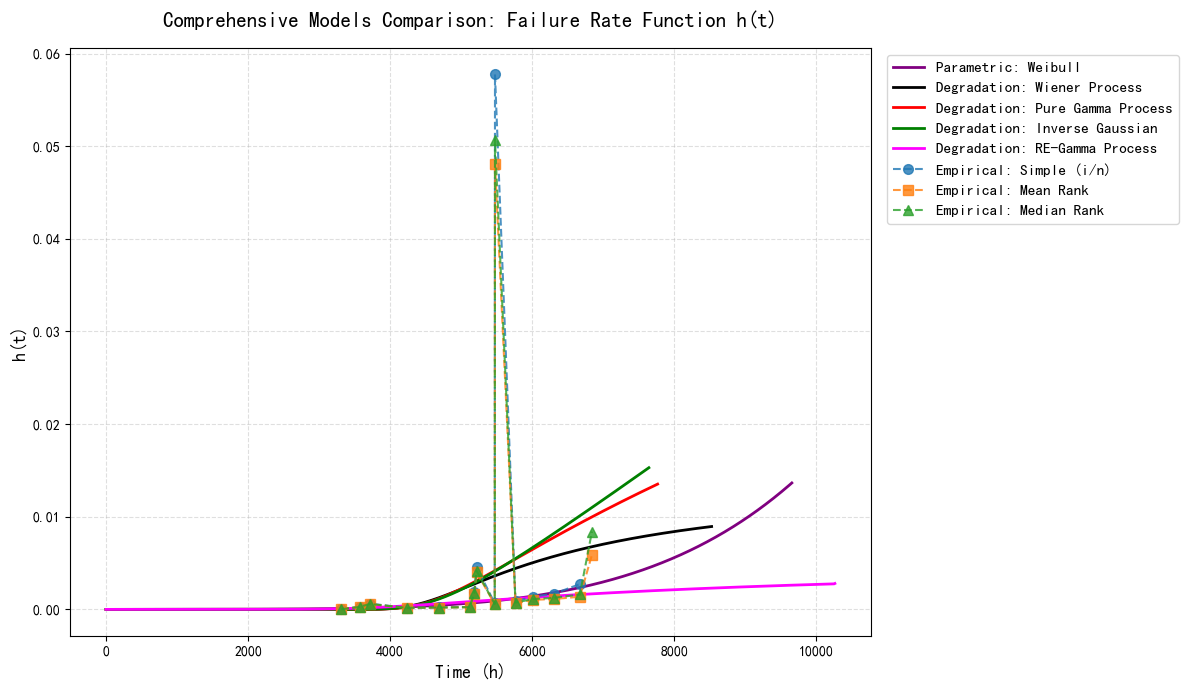

✓ 四大性能函数（包括 3经验、1参数、4退化模型）的最终版综合横向多维对比图绘制完毕。


In [30]:
# ================================================================
# Comprehensive Visual Comparison of ALL 8 Models:
# 3 Empirical + 1 Parametric (Weibull) + 4 Degradation Methods
# Plotted in 4 separate figures: PDF, CDF, Reliability, Failure Rate
# ================================================================
import matplotlib.pyplot as plt
import numpy as np

t_plot_all = np.linspace(1, ttf_data.max() * 1.5, 1000)

# --- 1. Parametric: Weibull ---
pdf_wb = stats.weibull_min.pdf(t_plot_all, shape_beta, loc=0, scale=scale_eta)
cdf_wb = stats.weibull_min.cdf(t_plot_all, shape_beta, loc=0, scale=scale_eta)
rel_wb = 1.0 - cdf_wb
haz_wb = pdf_wb / np.where(rel_wb > 1e-10, rel_wb, np.nan)

# --- 2. Degradation: Wiener Process ---
pdf_wp = wp_pdf(t_plot_all, mu_global, sigma2_global, threshold)
cdf_wp = wp_cdf(t_plot_all, mu_global, sigma2_global, threshold)
rel_wp = 1.0 - cdf_wp
haz_wp = pdf_wp / np.where(rel_wp > 1e-10, rel_wp, np.nan)

# --- 3. Degradation: Pure Gamma Process ---
cdf_gp = 1.0 - stats.gamma.cdf(threshold, a=alpha_hat * t_plot_all, scale=beta_hat)
pdf_gp = np.gradient(cdf_gp, t_plot_all)
rel_gp = 1.0 - cdf_gp
haz_gp = pdf_gp / np.where(rel_gp > 1e-10, rel_gp, np.nan)

# --- 4. Degradation: Inverse Gaussian Process ---
ig_m = (a_hat * t_plot_all) / (b_hat * t_plot_all**2)
ig_s = b_hat * t_plot_all**2
cdf_ig = 1.0 - stats.invgauss.cdf(threshold, mu=ig_m, scale=ig_s)
pdf_ig = np.gradient(cdf_ig, t_plot_all)
rel_ig = 1.0 - cdf_ig
haz_ig = pdf_ig / np.where(rel_ig > 1e-10, rel_ig, np.nan)

# --- 5. Degradation: Gamma process with Random Effects (RE-Gamma) ---
rel_reg = stats.beta.cdf(threshold / (threshold + gamma_re), a=alpha_re * t_plot_all, b=eps_re)
cdf_reg = 1.0 - rel_reg
pdf_reg = np.gradient(cdf_reg, t_plot_all)
haz_reg = pdf_reg / np.where(rel_reg > 1e-10, rel_reg, np.nan)

# ----------------------------------------------------------------
# PLOTTING THE 4 Separate Figures
# ----------------------------------------------------------------

c_params = [
    ('Parametric: Weibull',                  'purple',    '-'),
    ('Degradation: Wiener Process',          'black',     '-'),
    ('Degradation: Pure Gamma Process',      'red',       '-'),
    ('Degradation: Inverse Gaussian',        'green',     '-'),
    ('Degradation: RE-Gamma Process',        'magenta',   '-')
]

e_params = [
    ('Empirical: Simple (i/n)',              '#1f77b4',   'o'),
    ('Empirical: Mean Rank',                 '#ff7f0e',   's'),
    ('Empirical: Median Rank',               '#2ca02c',   '^')
]

metrics = [
    ('Probability Density Function (PDF)', 'f(t)', 
     [pdf_wb, pdf_wp, pdf_gp, pdf_ig, pdf_reg], [f_simple, f_mean, f_median], 'AllModels_PDF.png'),
    ('Cumulative Distribution Function (CDF)', 'F(t)', 
     [cdf_wb, cdf_wp, cdf_gp, cdf_ig, cdf_reg], [F_simple, F_mean, F_median], 'AllModels_CDF.png'),
    ('Reliability Function R(t)', 'R(t)', 
     [rel_wb, rel_wp, rel_gp, rel_ig, rel_reg], [R_simple, R_mean, R_median], 'AllModels_Reliability.png'),
    ('Failure Rate Function h(t)', 'h(t)', 
     [haz_wb, haz_wp, haz_gp, haz_ig, haz_reg], [h_simple, h_mean, h_median], 'AllModels_HazardRate.png')
]

for title, ylabel, c_datas, e_datas, fname in metrics:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot Series Models (Parametric + Degradation)
    for p, ydata in zip(c_params, c_datas):
        ax.plot(t_plot_all, ydata, label=p[0], color=p[1], linestyle=p[2], linewidth=2.0)
        
    # Plot Empirical Models
    for p, ydata in zip(e_params, e_datas):
        ax.plot(ttf_sorted, ydata, label=p[0], color=p[1], marker=p[2], 
                linestyle='--', linewidth=1.5, markersize=7, alpha=0.8)

    ax.set_title(f'Comprehensive Models Comparison: {title}', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Time (h)', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # 限制 Y 轴让图更好看 (避免部分函数发散产生视觉压缩)
    if 'PDF' in title or 'Hazard' in title:
        ax.set_ylim(-0.0001, np.nanmax([np.nanmax(yd) for yd in c_datas]) * 1.1)
    
    # 将 legend 放于外部以减少遮挡
    ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.01, 1), fancybox=True, shadow=False)
    fig.tight_layout()
    fig.savefig(f"{fname}.svg", bbox_inches='tight')
    fig.savefig(f"{fname}.pdf", bbox_inches='tight')
    plt.show()

print('=' * 80)
print('✓ 四大性能函数（包括 3经验、1参数、4退化模型）的最终版综合横向多维对比图绘制完毕。')
print('=' * 80)
